# Habitable Zone Candidate Identification
### COMP0050 Group Project — Stephan Vermeulen, Guanwen Zhou, Callum Harris, Ziqi Deng, Zhicong Deng

**Dataset:** NASA Exoplanet Archive Intelligence  
**Task:** Binary classification — predict whether an exoplanet lies within its host star's habitable zone (`habitable_zone_flag`)

---
**Notebook structure**
1. Data Cleaning  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering & Preprocessing  
4. Logistic Regression (5 models)  
5. Support Vector Machine (3 models)  
6. XGBoost (3 models)  
7. Cross-Model Comparison


## 1. Data Cleaning

In [54]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, classification_report,
    accuracy_score
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

### 1.1 Load raw data

In [55]:
path = 'nasa_exoplanet_intelligence.csv'
df_raw = pd.read_csv(path)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (6150, 31)


,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [56]:
print(df_raw.dtypes)
print()
print(df_raw.describe())

planet_name              object
host_star                object
n_stars                   int64
n_planets                 int64
discovery_method         object
disc_year               float64
disc_facility            object
orbital_period_days     float64
planet_radius_earth     float64
planet_mass_earth       float64
equilibrium_temp_k      float64
orbital_eccentricity    float64
semi_major_axis_au      float64
star_temp_k             float64
star_radius_sun         float64
star_mass_sun           float64
star_age_gyr            float64
star_surface_gravity    float64
star_metallicity        float64
dist_from_earth_pc      float64
star_vmag               float64
ra                      float64
dec                     float64
controversial_flag        int64
planet_type              object
habitable_zone_flag        bool
multi_planet_system        bool
is_recent_discovery        bool
dist_category            object
star_type                object
orbital_period_cat       object
dtype: o

### 1.2 Missingness

In [57]:
# Check duplicates
print(f"Duplicate rows: {df_raw.duplicated().sum()}")

df = df_raw.copy()

# Drop irrelevant columns
df = df.drop(columns=['controversial_flag', 'planet_name', 'host_star',
                       'disc_year', 'disc_facility', 'ra', 'dec'])

# Drop high-missingness / low-importance columns
df = df.drop(columns=['star_age_gyr', 'orbital_eccentricity', 'equilibrium_temp_k'])

print("\nMissing values after column drops:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values after column drops:
n_stars                   0
n_planets                 0
discovery_method          0
orbital_period_days     334
planet_radius_earth      50
planet_mass_earth        31
semi_major_axis_au      316
star_temp_k             290
star_radius_sun         314
star_mass_sun             8
star_surface_gravity    318
star_metallicity        550
dist_from_earth_pc       27
star_vmag               295
planet_type               0
habitable_zone_flag       0
multi_planet_system       0
is_recent_discovery       0
dist_category             0
star_type                 0
orbital_period_cat        0
dtype: int64


In [58]:
# Drop rows where critical features are missing (co-missing pattern)
df = df.dropna(subset=['orbital_period_days', 'star_temp_k',
                        'star_radius_sun', 'star_surface_gravity',
                        'star_vmag', 'semi_major_axis_au'])

# Median imputation for remaining columns
# NOTE: computed on full dataset before split — minor leakage, noted as limitation
median_cols = ['planet_radius_earth', 'planet_mass_earth',
               'dist_from_earth_pc', 'star_mass_sun', 'star_metallicity']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())
print(f"\nFinal cleaned dataset shape: {df.shape}")

Missing values after imputation:
n_stars                 0
n_planets               0
discovery_method        0
orbital_period_days     0
planet_radius_earth     0
planet_mass_earth       0
semi_major_axis_au      0
star_temp_k             0
star_radius_sun         0
star_mass_sun           0
star_surface_gravity    0
star_metallicity        0
dist_from_earth_pc      0
star_vmag               0
planet_type             0
habitable_zone_flag     0
multi_planet_system     0
is_recent_discovery     0
dist_category           0
star_type               0
orbital_period_cat      0
dtype: int64

Final cleaned dataset shape: (5451, 21)


### 1.3 Outlier Detection

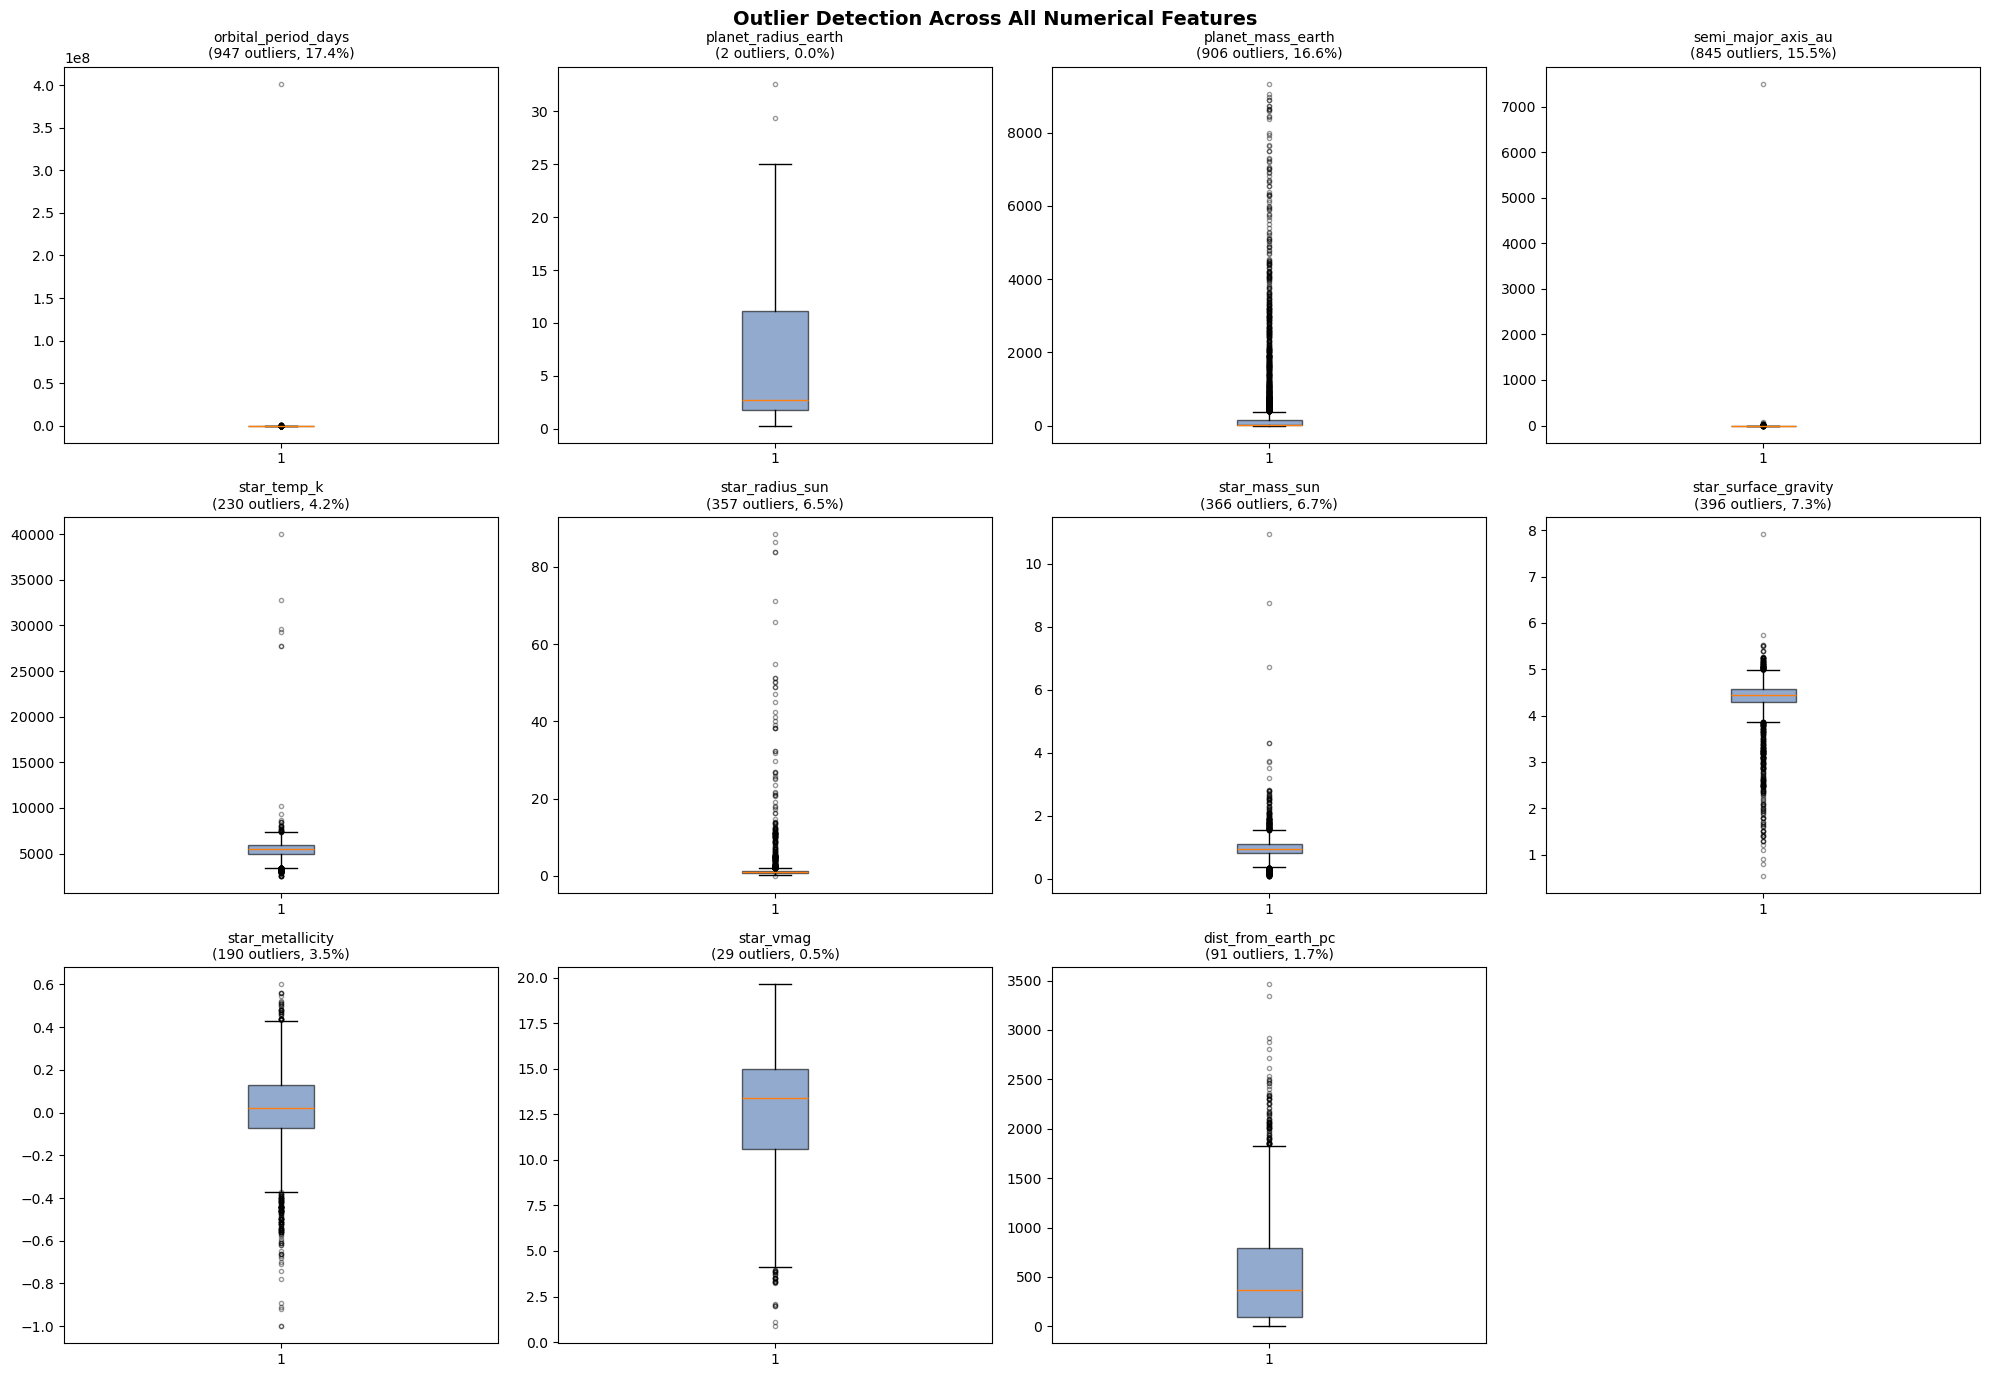

In [59]:
num_cols = ['orbital_period_days', 'planet_radius_earth', 'planet_mass_earth',
            'semi_major_axis_au', 'star_temp_k', 'star_radius_sun',
            'star_mass_sun', 'star_surface_gravity', 'star_metallicity',
            'star_vmag', 'dist_from_earth_pc']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6),
               flierprops=dict(marker='o', markersize=3, alpha=0.4, color='red'))
    ax.set_title(f'{col}\n({n_out} outliers, {n_out/len(data)*100:.1f}%)', fontsize=10)

axes[2, 3].axis('off')
plt.suptitle('Outlier Detection Across All Numerical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()
# Outliers retained — genuine astrophysical objects, not measurement errors

In [60]:
# Save cleaned CSV for modelling notebooks
df.to_csv('exoplanet_clean.csv', index=False)
print("Saved exoplanet_clean.csv")

Saved exoplanet_clean.csv


## 2. Exploratory Data Analysis

### 2.1 Target Variable — Class Imbalance

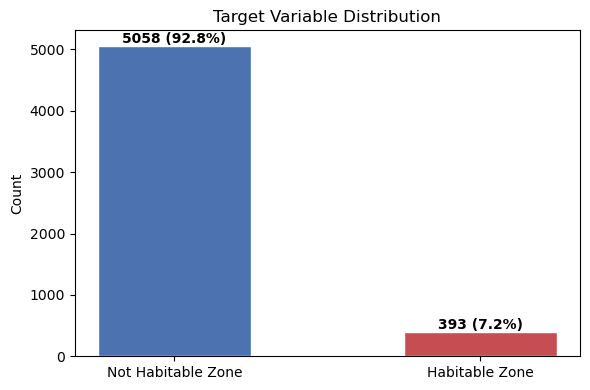

Positive class (HZ): 393 (7.2%)
Negative class (non-HZ): 5058 (92.8%)


In [61]:
counts = df['habitable_zone_flag'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Not Habitable Zone', 'Habitable Zone'],
       [counts[False], counts[True]], color=['#4C72B0', '#C44E52'],
       edgecolor='white', width=0.5)

for i, v in enumerate([counts[False], counts[True]]):
    ax.text(i, v + 50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution')
plt.tight_layout()
plt.show()

print(f"Positive class (HZ): {counts[True]} ({counts[True]/len(df)*100:.1f}%)")
print(f"Negative class (non-HZ): {counts[False]} ({counts[False]/len(df)*100:.1f}%)")

### 2.2 Feature Distributions: HZ vs Non-HZ

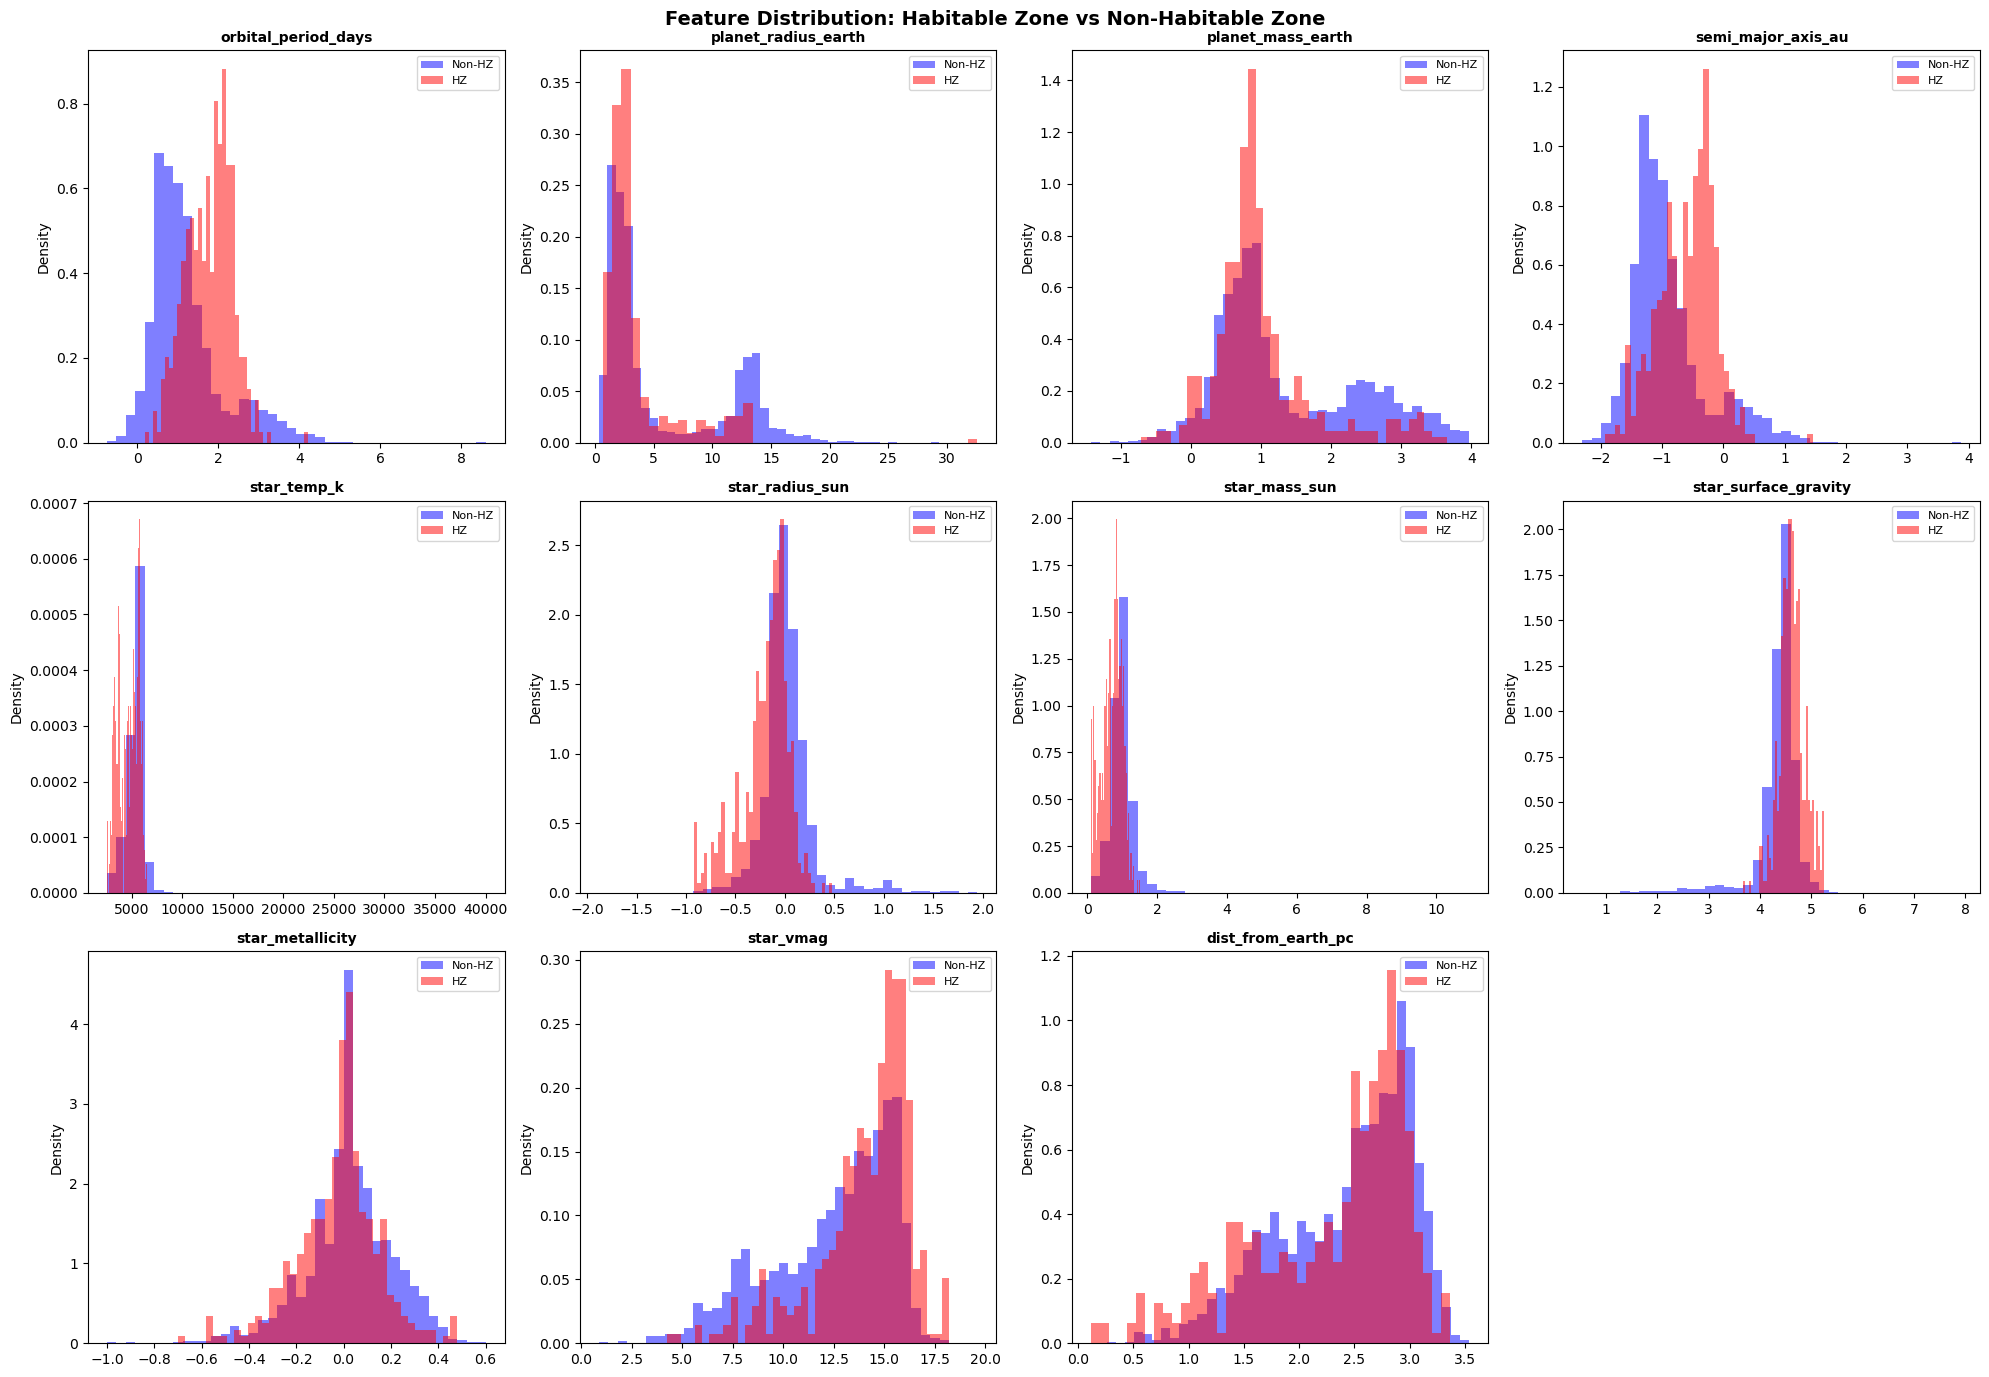

In [62]:
log_cols_viz = ['orbital_period_days', 'planet_mass_earth', 'semi_major_axis_au',
                'star_radius_sun', 'dist_from_earth_pc']

hz = df[df['habitable_zone_flag'] == True]
non_hz = df[df['habitable_zone_flag'] == False]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))

for i, col in enumerate(num_cols):
    ax = axes[i // 4, i % 4]
    hz_data = hz[col]
    non_hz_data = non_hz[col]
    if col in log_cols_viz:
        hz_data = np.log10(hz_data[hz_data > 0])
        non_hz_data = np.log10(non_hz_data[non_hz_data > 0])
    ax.hist(non_hz_data, bins=40, alpha=0.5, color='blue', label='Non-HZ', density=True)
    ax.hist(hz_data, bins=40, alpha=0.5, color='red', label='HZ', density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

axes[2, 3].axis('off')
plt.suptitle('Feature Distribution: Habitable Zone vs Non-Habitable Zone',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Feature–Target Correlation

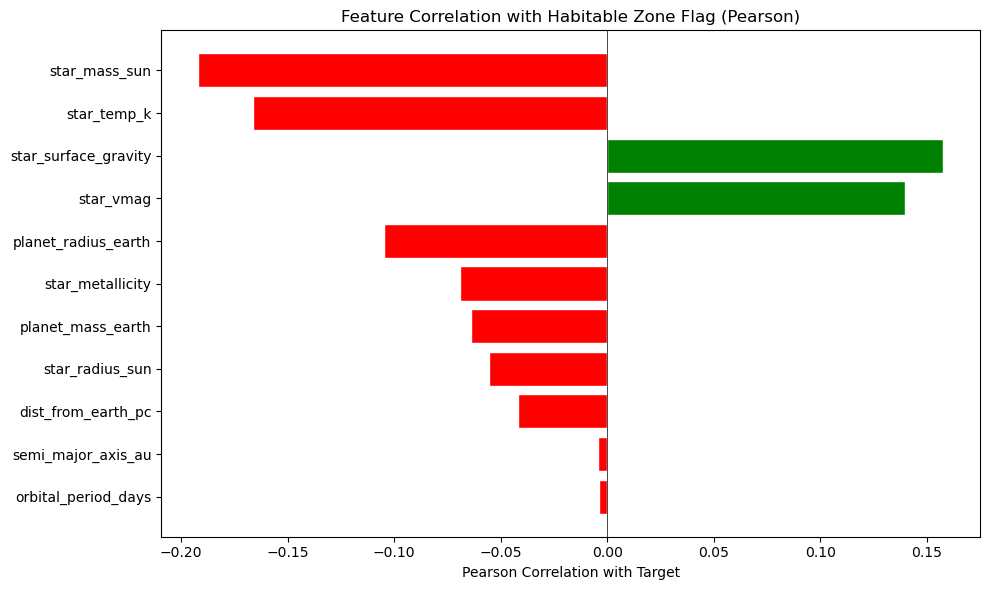

In [63]:
target_int = df['habitable_zone_flag'].astype(int)

# Pearson
corrs = df[num_cols].corrwith(target_int).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if r > 0 else 'red' for r in corrs.values]
ax.barh(corrs.index[::-1], corrs.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Pearson Correlation with Target')
ax.set_title('Feature Correlation with Habitable Zone Flag (Pearson)')
plt.tight_layout()
plt.show()

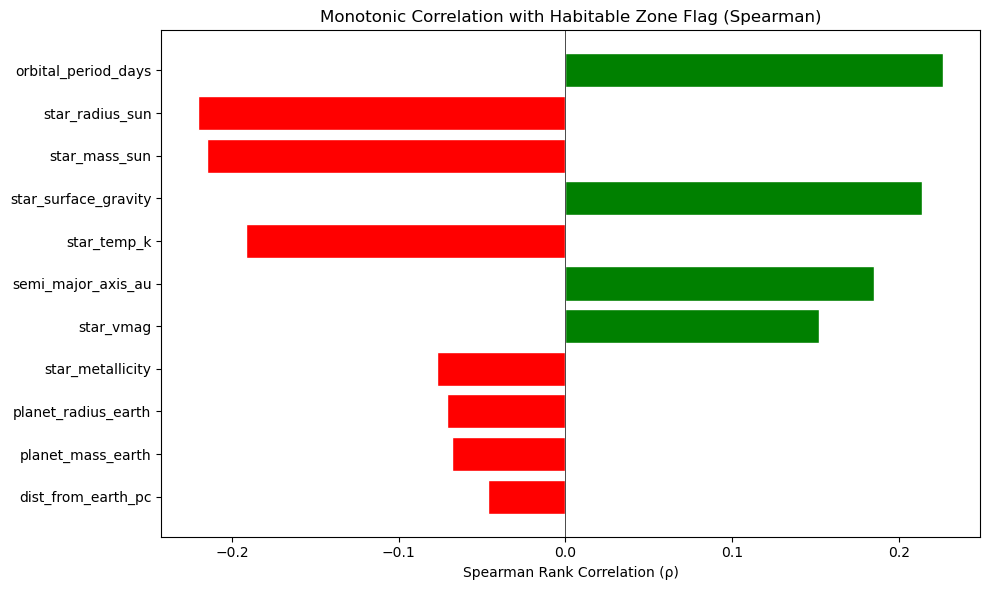

             feature     rho  p_value
 orbital_period_days  0.2264 0.000000
     star_radius_sun -0.2202 0.000000
       star_mass_sun -0.2148 0.000000
star_surface_gravity  0.2139 0.000000
         star_temp_k -0.1918 0.000000
  semi_major_axis_au  0.1852 0.000000
           star_vmag  0.1520 0.000000
    star_metallicity -0.0769 0.000000
 planet_radius_earth -0.0713 0.000000
   planet_mass_earth -0.0679 0.000001
  dist_from_earth_pc -0.0464 0.000618


In [64]:
# Spearman
sp_results = []
for col in num_cols:
    valid = df[col].notna()
    rho, p = stats.spearmanr(target_int[valid], df.loc[valid, col])
    sp_results.append({'feature': col, 'rho': round(rho, 4), 'p_value': round(p, 6)})

sp_df = pd.DataFrame(sp_results).sort_values('rho', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if r > 0 else 'red' for r in sp_df['rho']]
ax.barh(sp_df['feature'][::-1], sp_df['rho'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Spearman Rank Correlation (ρ)')
ax.set_title('Monotonic Correlation with Habitable Zone Flag (Spearman)')
plt.tight_layout()
plt.show()
print(sp_df.to_string(index=False))

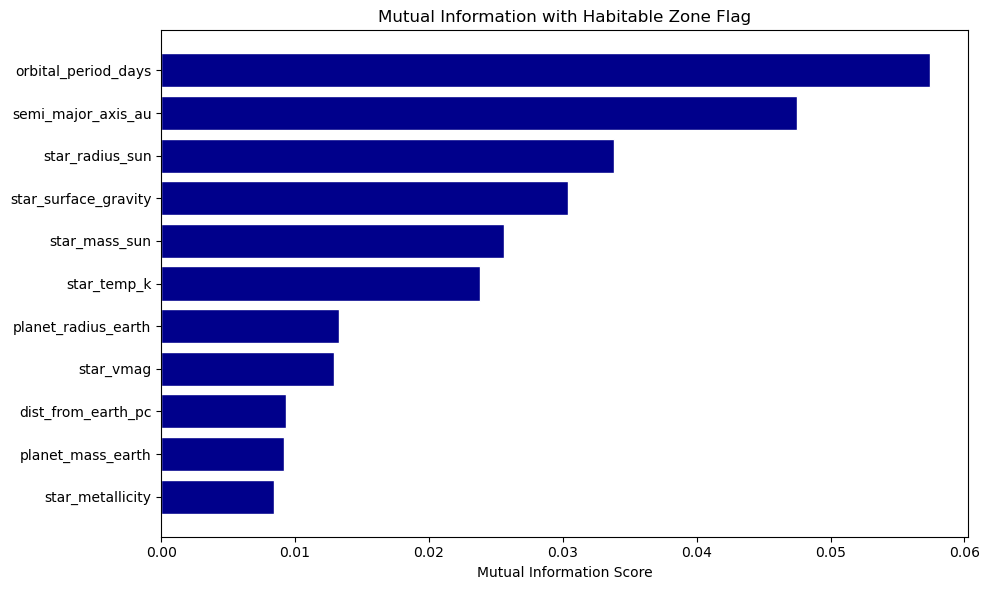

             feature     MI
 orbital_period_days 0.0574
  semi_major_axis_au 0.0475
     star_radius_sun 0.0338
star_surface_gravity 0.0304
       star_mass_sun 0.0256
         star_temp_k 0.0238
 planet_radius_earth 0.0133
           star_vmag 0.0129
  dist_from_earth_pc 0.0093
   planet_mass_earth 0.0092
    star_metallicity 0.0084


In [65]:
# Mutual Information
mi_df = df[num_cols].copy()
for col in mi_df.columns:
    mi_df[col] = mi_df[col].fillna(mi_df[col].median())

mi_scores = mutual_info_classif(mi_df, target_int, random_state=42)
mi_result = pd.DataFrame({'feature': num_cols, 'MI': np.round(mi_scores, 4)})
mi_result = mi_result.sort_values('MI', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(mi_result['feature'][::-1], mi_result['MI'][::-1], color='darkblue', edgecolor='white')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information with Habitable Zone Flag')
plt.tight_layout()
plt.show()
print(mi_result.to_string(index=False))

### 2.4 Feature–Feature Correlation Heatmap

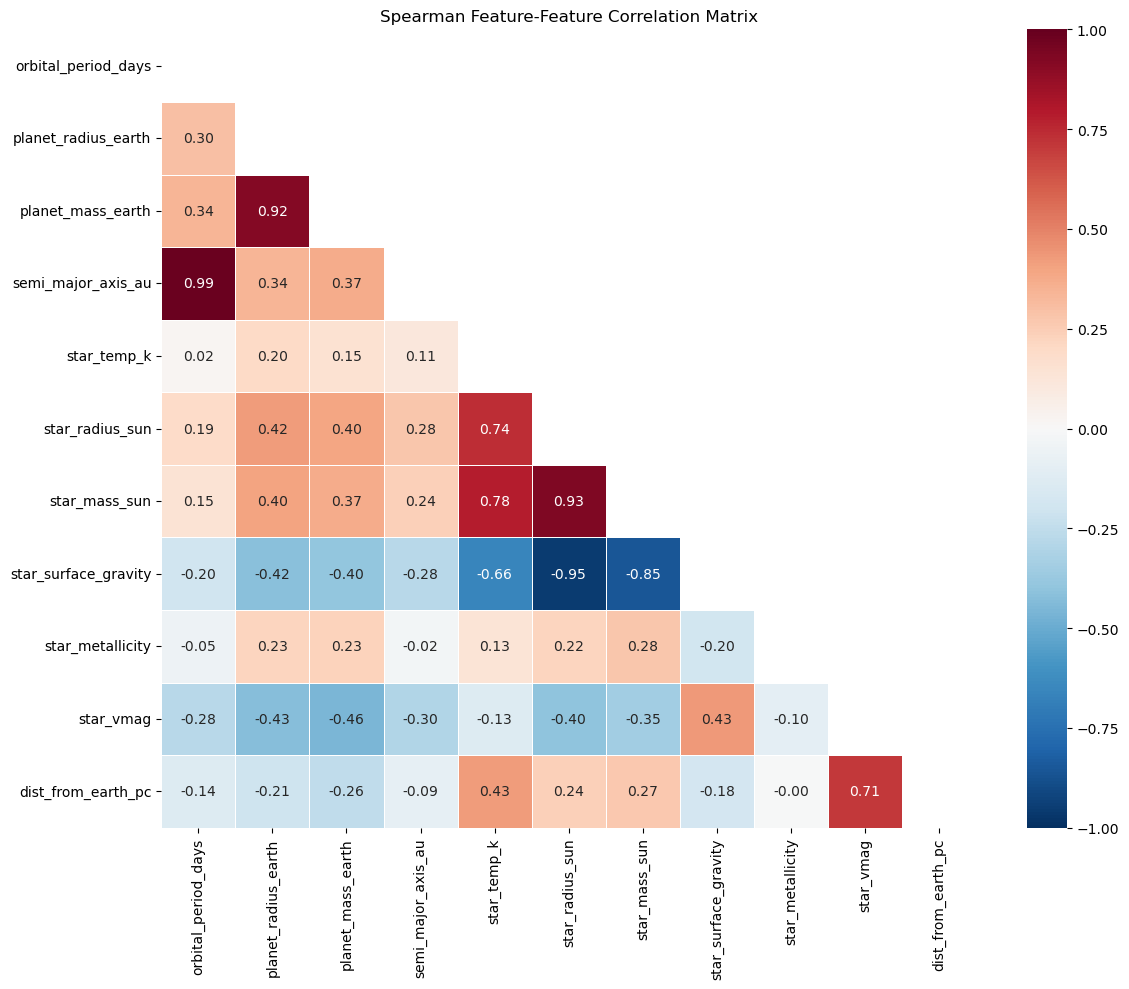

Pairs with |ρ| > 0.8 (multicollinearity concern):
  orbital_period_days — semi_major_axis_au: 0.99
  planet_radius_earth — planet_mass_earth: 0.92
  star_radius_sun — star_mass_sun: 0.93
  star_radius_sun — star_surface_gravity: -0.95
  star_mass_sun — star_surface_gravity: -0.85


In [66]:
corr_matrix = df[num_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Spearman Feature-Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
print("Pairs with |ρ| > 0.8 (multicollinearity concern):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"  {corr_matrix.index[i]} — {corr_matrix.columns[j]}: {corr_matrix.iloc[i,j]:.2f}")

### 2.5 Categorical Feature Analysis

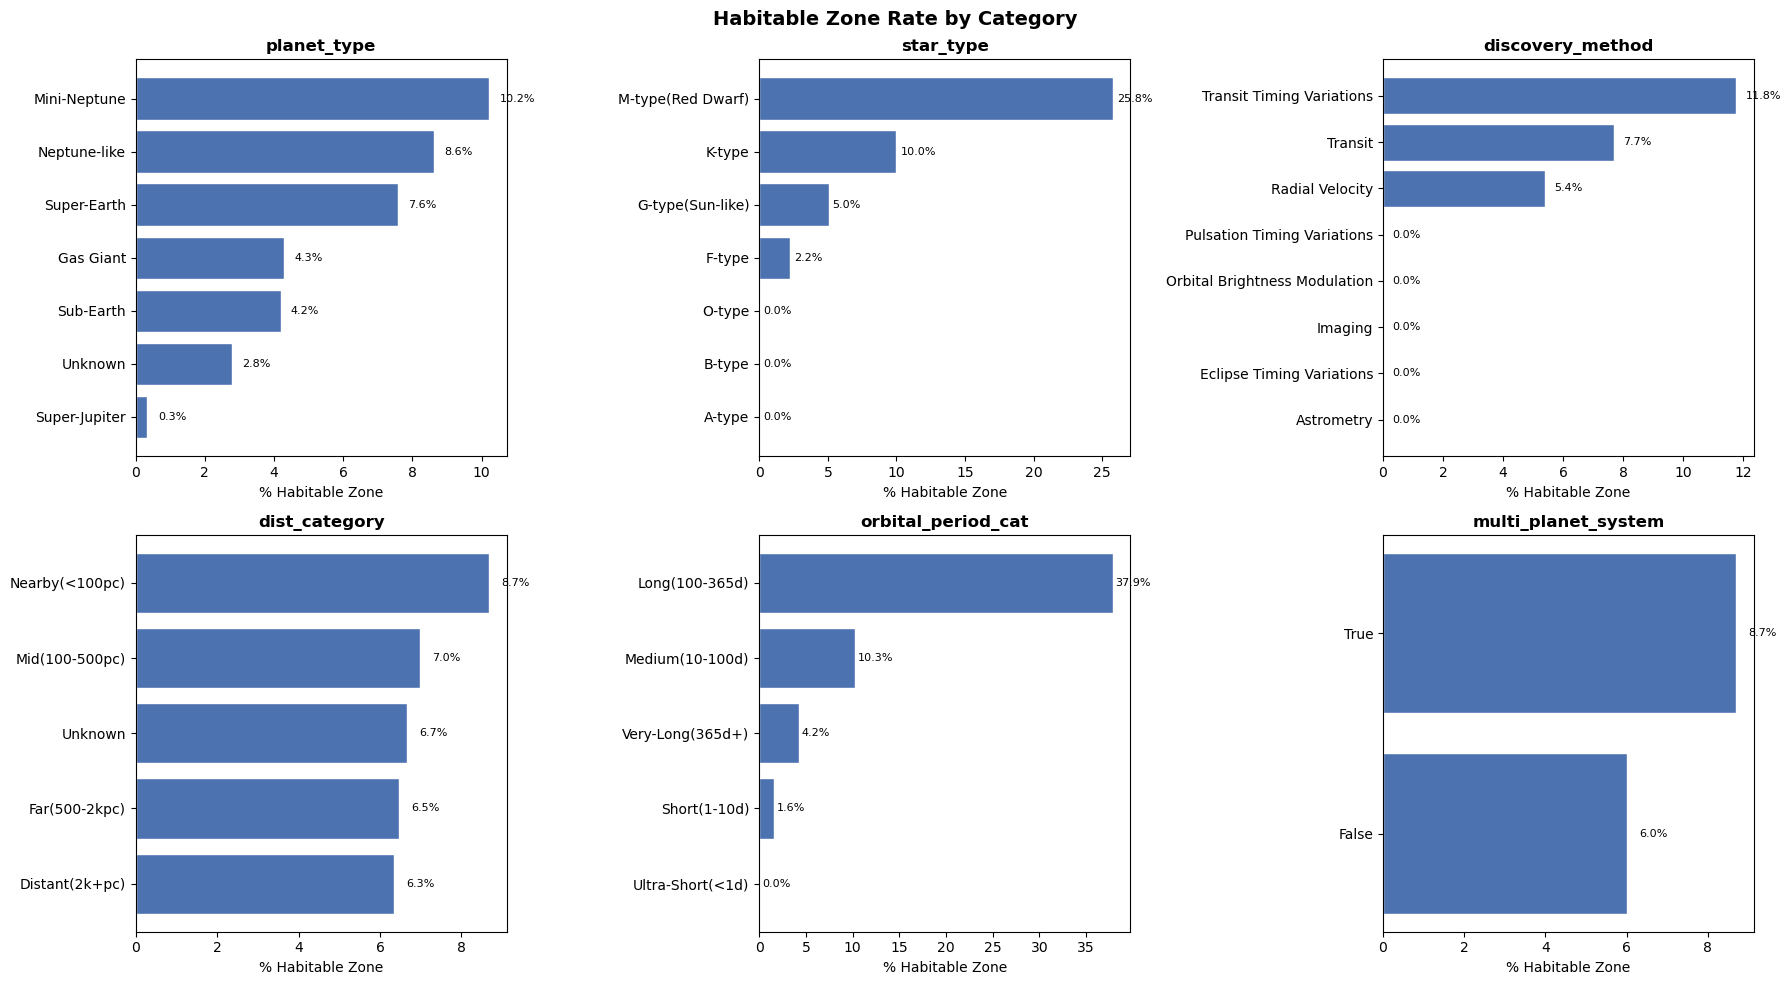

In [67]:
cat_cols = ['planet_type', 'star_type', 'discovery_method',
            'dist_category', 'orbital_period_cat', 'multi_planet_system']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, col in enumerate(cat_cols):
    ax = axes[i // 3, i % 3]
    rates = df.groupby(col)['habitable_zone_flag'].mean().sort_values(ascending=True) * 100
    ax.barh(rates.index.astype(str), rates.values, color='#4C72B0', edgecolor='white')
    for bar, val in zip(ax.patches, rates.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.set_xlabel('% Habitable Zone')
    ax.set_title(col, fontweight='bold')

plt.suptitle('Habitable Zone Rate by Category', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 2.6 PCA Projection

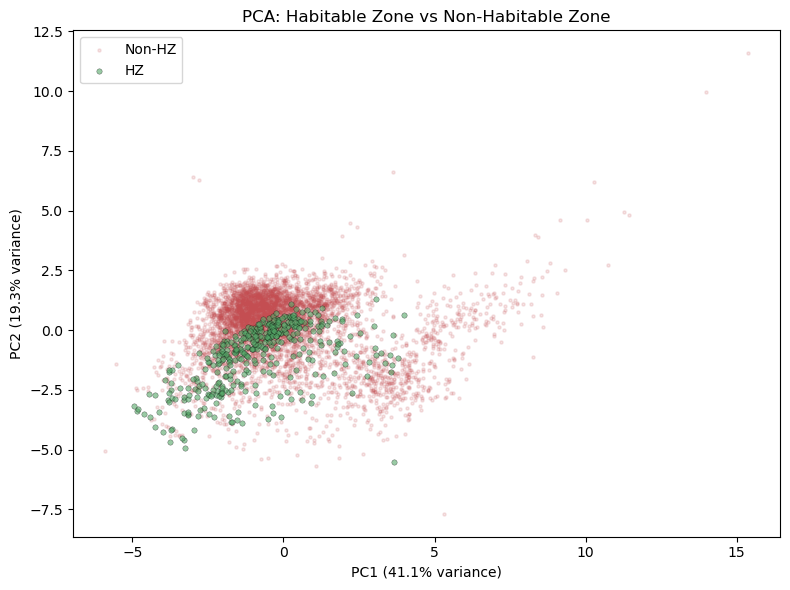

Total variance explained by 2 PCs: 60.5%


In [68]:
pca_df = df[num_cols].copy()
log_cols_pca = ['orbital_period_days', 'planet_mass_earth', 'semi_major_axis_au',
                'star_radius_sun', 'dist_from_earth_pc']
for col in log_cols_pca:
    pca_df[col] = np.log10(pca_df[col].clip(lower=0.001))
for col in pca_df.columns:
    pca_df[col] = pca_df[col].fillna(pca_df[col].median())

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(pca_df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_pca)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca[target_int == 0, 0], X_pca[target_int == 0, 1],
           alpha=0.15, s=5, c='#C44E52', label='Non-HZ')
ax.scatter(X_pca[target_int == 1, 0], X_pca[target_int == 1, 1],
           alpha=0.6, s=15, c='#55A868', label='HZ', edgecolors='black', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA: Habitable Zone vs Non-Habitable Zone')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 3. Feature Engineering & Preprocessing

### 3.1 Feature Engineering (applied to all models)

In [69]:
df_feat = df.copy()

# Log transformations (reduce right-skew)
log_cols_fe = ['orbital_period_days', 'planet_mass_earth', 'semi_major_axis_au', 'dist_from_earth_pc']
for col in log_cols_fe:
    df_feat[f'log_{col}'] = np.log10(df_feat[col] + 1e-6)

# Planet density proxy
df_feat['planet_density_proxy'] = df_feat['planet_mass_earth'] / (df_feat['planet_radius_earth'] ** 3)

# Stellar flux proxy: (T_star/T_sun)^4 * R_star^2 / a^2
df_feat['stellar_flux'] = ((df_feat['star_temp_k'] / 5778) ** 4 * df_feat['star_radius_sun'] ** 2) /                            (df_feat['semi_major_axis_au'] ** 2)

# Relative orbital distance
df_feat['rel_dist_to_star_mass'] = df_feat['semi_major_axis_au'] / df_feat['star_mass_sun']

print("New engineered features added:")
new_cols = [c for c in df_feat.columns if c not in df.columns]
print(new_cols)

New engineered features added:
['log_orbital_period_days', 'log_planet_mass_earth', 'log_semi_major_axis_au', 'log_dist_from_earth_pc', 'planet_density_proxy', 'stellar_flux', 'rel_dist_to_star_mass']


### 3.2 Categorical Encoding (used by SVM; noted as limitation for LR/XGB)

**Encoding strategy:**
- **Ordinal:** `dist_category`, `orbital_period_cat` (natural order preserved)
- **One-hot:** `planet_type`, `star_type`, `discovery_method` (rare categories → `Other`)
- **Boolean:** cast to 0/1

> **Note:** LR and XGBoost use numerical features only (see Sections 4 & 6).  
> SVM uses the full encoded feature set. This difference is acknowledged as a limitation.


In [70]:
df_encoded = df_feat.copy()

# Boolean encoding
bool_cols = ['habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery']
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

# Ordinal encoding
dist_order = {'Nearby(<100pc)': 0, 'Mid(100-500pc)': 1,
              'Far(500-2kpc)': 2, 'Distant(2k+pc)': 3, 'Unknown': 1}
period_order = {'Ultra-Short(<1d)': 0, 'Short(1-10d)': 1, 'Medium(10-100d)': 2,
                'Long(100-365d)': 3, 'Very-Long(365d+)': 4}

df_encoded['dist_category'] = df_encoded['dist_category'].map(dist_order)
df_encoded['orbital_period_cat'] = df_encoded['orbital_period_cat'].map(period_order)

# One-hot encoding (rare categories merged)
one_hot_cols = ['planet_type', 'star_type', 'discovery_method']
for col in one_hot_cols:
    cur_col = df_encoded[col].copy()
    rare = cur_col.value_counts()[lambda x: x < 50].index
    cur_col = cur_col.replace(rare, 'Other')
    dummies = pd.get_dummies(cur_col, prefix=col).astype(int)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
df_encoded = df_encoded.drop(columns=one_hot_cols)

print("Encoded dataframe shape:", df_encoded.shape)
print("dtypes sample:")
print(df_encoded.dtypes.value_counts())

Encoded dataframe shape: (5451, 40)
dtypes sample:
int64      22
float64    18
Name: count, dtype: int64


## 4. Shared Evaluation Functions

In [71]:
def evaluate_probabilities(y_true, y_prob, threshold=0.5, model_name="Model"):
    """Plot confusion matrix, ROC, PR curves and print metrics."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay(cm, display_labels=["Not Habitable", "Habitable"]).plot(
        ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
    axes[0].set_title(f"Confusion Matrix ({model_name})")

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"ROC Curve ({model_name})")
    axes[1].legend()

    axes[2].plot(recall_curve, precision_curve, label=f"AP = {pr_auc:.3f}")
    axes[2].set_xlabel("Recall")
    axes[2].set_ylabel("Precision")
    axes[2].set_title(f"Precision-Recall Curve ({model_name})")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    m = {
        "threshold": threshold, "roc_auc": roc_auc, "pr_auc": pr_auc,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }
    print(f"\n{model_name} @ threshold={threshold:.3f}")
    for k, v in m.items():
        print(f"  {k}: {v:.4f}" if k != "threshold" else f"  {k}: {v:.3f}")
    print("\n" + classification_report(y_true, y_pred, zero_division=0))
    return m


def find_best_threshold(y_true, y_prob, n_grid=201):
    """Find threshold maximising F1 on a validation set."""
    thresholds = np.linspace(0, 1, n_grid)
    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "f1": f1_score(y_true, y_pred_t, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    best_t = threshold_df.loc[threshold_df["f1"].idxmax(), "threshold"]

    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
    plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
    plt.axvline(best_t, linestyle="--", color="black", label=f"Best = {best_t:.3f}")
    plt.xlabel("Threshold"); plt.ylabel("Score")
    plt.title("Validation-set Threshold Tuning")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

    return best_t, threshold_df

## 5. Logistic Regression

**Feature set:** numerical + engineered features only (no categorical encoding)  
**Split:** 60% train / 20% validation / 20% test (stratified)  
**Imbalance:** `class_weight='balanced'` + SMOTE (evaluated separately)  
**Optimisation metric:** Average Precision (PR-AUC)


In [72]:
# Feature set for LR and XGBoost
lr_features = [
    "semi_major_axis_au", "orbital_period_days", "star_temp_k",
    "star_radius_sun", "star_mass_sun", "star_metallicity",
    "planet_mass_earth", "multi_planet_system",
    "stellar_flux", "log_semi_major_axis_au", "log_orbital_period_days",
]

# Add interaction term (LR-specific)
df_lr = df_feat.copy()
df_lr["habitable_zone_flag"] = df_lr["habitable_zone_flag"].astype(int)
df_lr["multi_planet_system"] = df_lr["multi_planet_system"].astype(int)
df_lr["log_star_temp"] = np.log(df_lr["star_temp_k"])
df_lr["temp_distance_interaction"] = df_lr["star_temp_k"] * df_lr["semi_major_axis_au"]

lr_features_full = lr_features + ["log_star_temp", "temp_distance_interaction"]

df_lr_model = df_lr[lr_features_full + ["habitable_zone_flag"]].dropna().copy()
X_lr = df_lr_model[lr_features_full]
y_lr = df_lr_model["habitable_zone_flag"]

print("LR model data shape:", df_lr_model.shape)
print("\nClass distribution:")
print(y_lr.value_counts(normalize=True).rename("proportion"))

LR model data shape: (5451, 14)

Class distribution:
habitable_zone_flag
0    0.927903
1    0.072097
Name: proportion, dtype: float64


In [73]:
# 60/20/20 stratified split
X_lr_temp, X_lr_test, y_lr_temp, y_lr_test = train_test_split(
    X_lr, y_lr, test_size=0.20, stratify=y_lr, random_state=42)
X_lr_train, X_lr_val, y_lr_train, y_lr_val = train_test_split(
    X_lr_temp, y_lr_temp, test_size=0.25, stratify=y_lr_temp, random_state=42)

print(f"Train: {X_lr_train.shape}, Val: {X_lr_val.shape}, Test: {X_lr_test.shape}")
print(f"Train class balance: {dict(y_lr_train.value_counts())}")

Train: (3270, 13), Val: (1090, 13), Test: (1091, 13)
Train class balance: {0: np.int64(3034), 1: np.int64(236)}


### 5.1 Model 1 — Baseline L2 (threshold = 0.5)

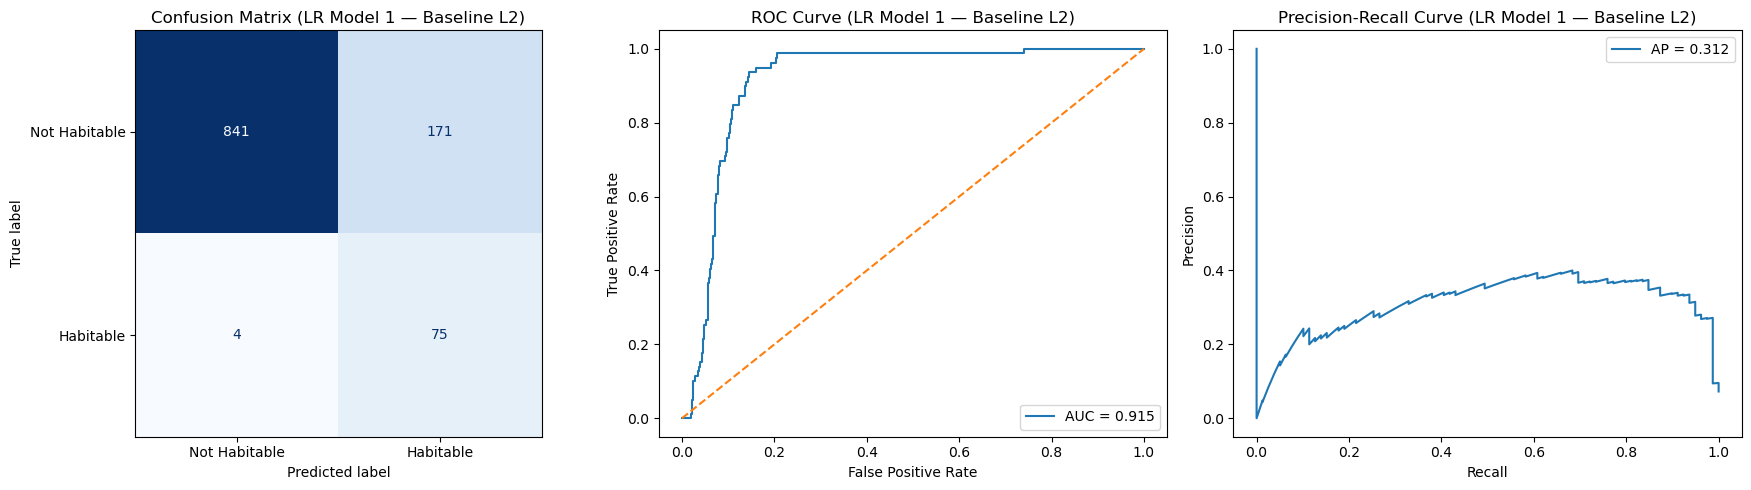


LR Model 1 — Baseline L2 @ threshold=0.500
  threshold: 0.500
  roc_auc: 0.9149
  pr_auc: 0.3123
  precision: 0.3049
  recall: 0.9494
  f1: 0.4615

              precision    recall  f1-score   support

           0       1.00      0.83      0.91      1012
           1       0.30      0.95      0.46        79

    accuracy                           0.84      1091
   macro avg       0.65      0.89      0.68      1091
weighted avg       0.95      0.84      0.87      1091



In [74]:
baseline_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                  max_iter=1000, random_state=42))
])
baseline_pipe.fit(X_lr_train, y_lr_train)

val_prob_lr_base = baseline_pipe.predict_proba(X_lr_val)[:, 1]
test_prob_lr_base = baseline_pipe.predict_proba(X_lr_test)[:, 1]

lr_m1 = evaluate_probabilities(y_lr_test, test_prob_lr_base, 0.5, "LR Model 1 — Baseline L2")

### 5.2 Model 2 — Tuned (L1/L2 grid search, threshold = 0.5)

Best params: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV PR-AUC: 0.5254


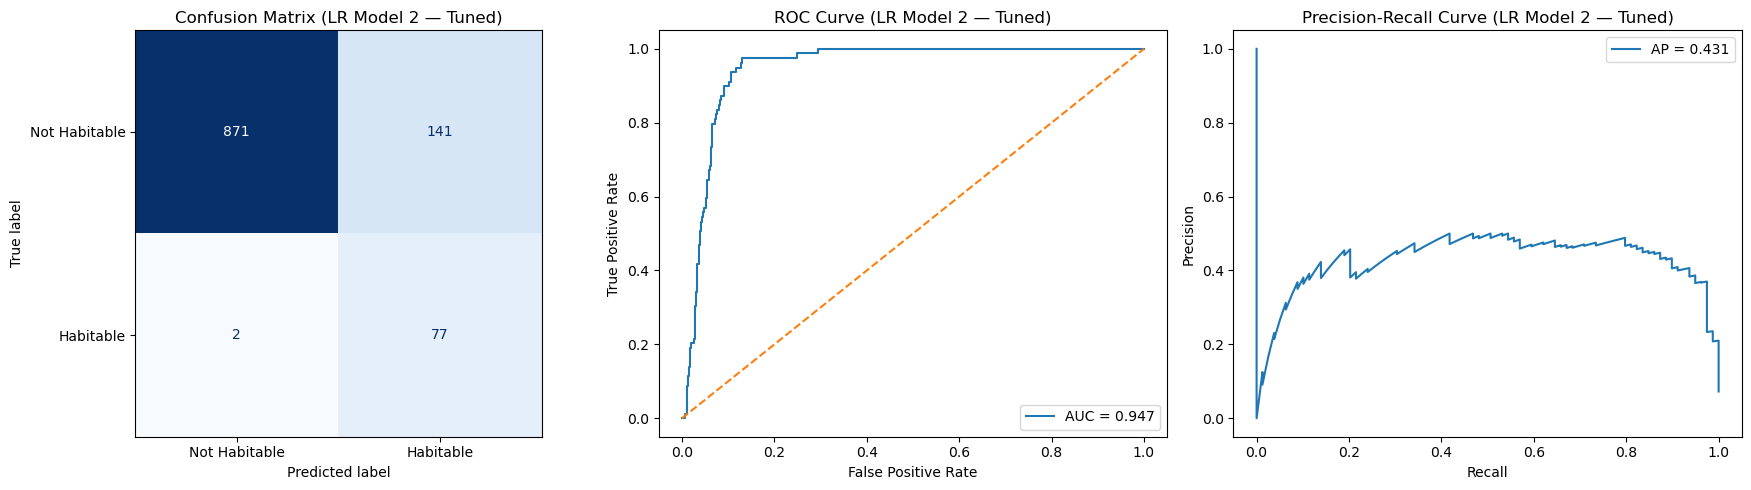


LR Model 2 — Tuned @ threshold=0.500
  threshold: 0.500
  roc_auc: 0.9472
  pr_auc: 0.4308
  precision: 0.3532
  recall: 0.9747
  f1: 0.5185

              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1012
           1       0.35      0.97      0.52        79

    accuracy                           0.87      1091
   macro avg       0.68      0.92      0.72      1091
weighted avg       0.95      0.87      0.89      1091



In [75]:
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}
tuned_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
grid_lr = GridSearchCV(tuned_pipe, param_grid_lr, cv=5,
                       scoring={"roc_auc": "roc_auc", "average_precision": "average_precision"},
                       refit="average_precision", n_jobs=-1)
grid_lr.fit(X_lr_train, y_lr_train)
print("Best params:", grid_lr.best_params_)
print("Best CV PR-AUC:", round(grid_lr.best_score_, 4))

best_lr_model = grid_lr.best_estimator_
val_prob_lr_tuned = best_lr_model.predict_proba(X_lr_val)[:, 1]
test_prob_lr_tuned = best_lr_model.predict_proba(X_lr_test)[:, 1]

lr_m2 = evaluate_probabilities(y_lr_test, test_prob_lr_tuned, 0.5, "LR Model 2 — Tuned")

### 5.3 Model 3 — Tuned + Threshold Tuning (best F1)

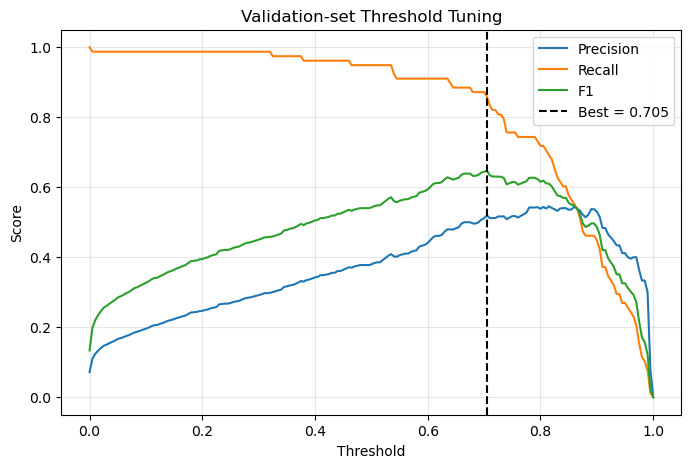

Best validation threshold: 0.705


,threshold,precision,recall,f1
141,0.705,0.519380,0.858974,0.647343
140,0.700,0.511278,0.871795,0.644550
139,0.695,0.507463,0.871795,0.641509
133,0.665,0.500000,0.884615,0.638889
134,0.670,0.500000,0.884615,0.638889


In [76]:
best_t_lr, t_table_lr = find_best_threshold(y_lr_val, val_prob_lr_tuned)
print("Best validation threshold:", round(best_t_lr, 3))
t_table_lr.sort_values("f1", ascending=False).head()

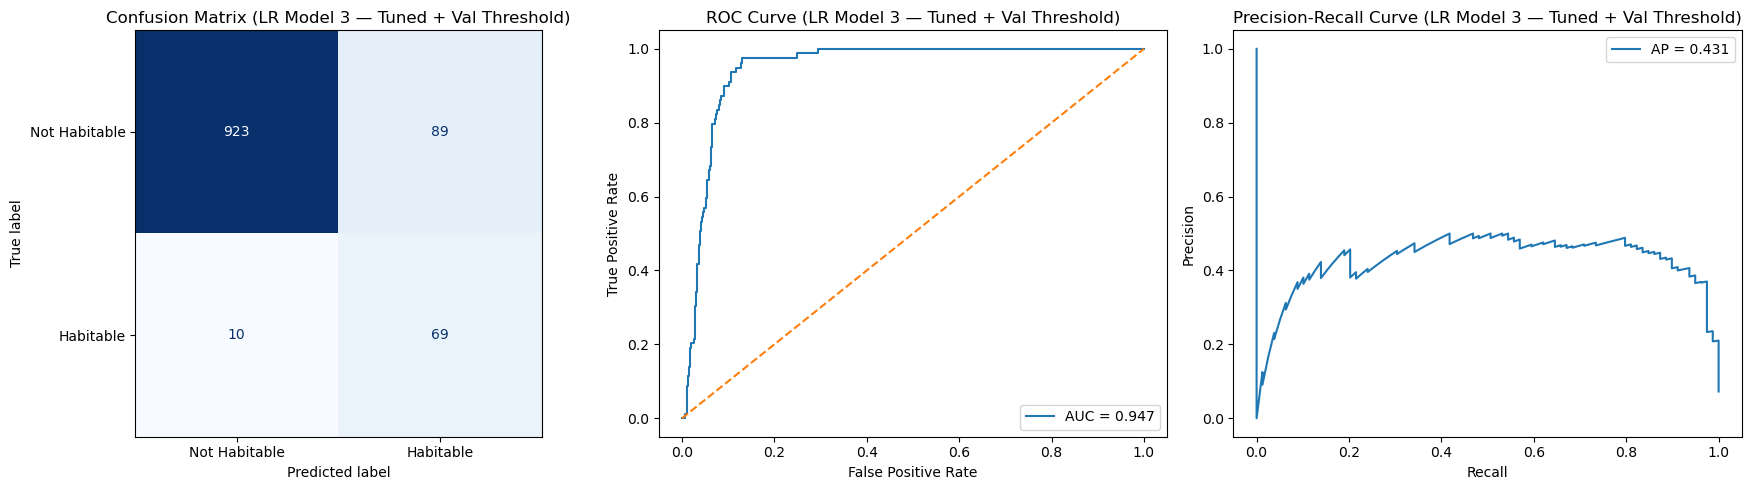


LR Model 3 — Tuned + Val Threshold @ threshold=0.705
  threshold: 0.705
  roc_auc: 0.9472
  pr_auc: 0.4308
  precision: 0.4367
  recall: 0.8734
  f1: 0.5823

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1012
           1       0.44      0.87      0.58        79

    accuracy                           0.91      1091
   macro avg       0.71      0.89      0.77      1091
weighted avg       0.95      0.91      0.92      1091



In [77]:
lr_m3 = evaluate_probabilities(y_lr_test, test_prob_lr_tuned, best_t_lr,
                               "LR Model 3 — Tuned + Val Threshold")

### 5.4 Model 4 — SMOTE (threshold = 0.5)

Best SMOTE params: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


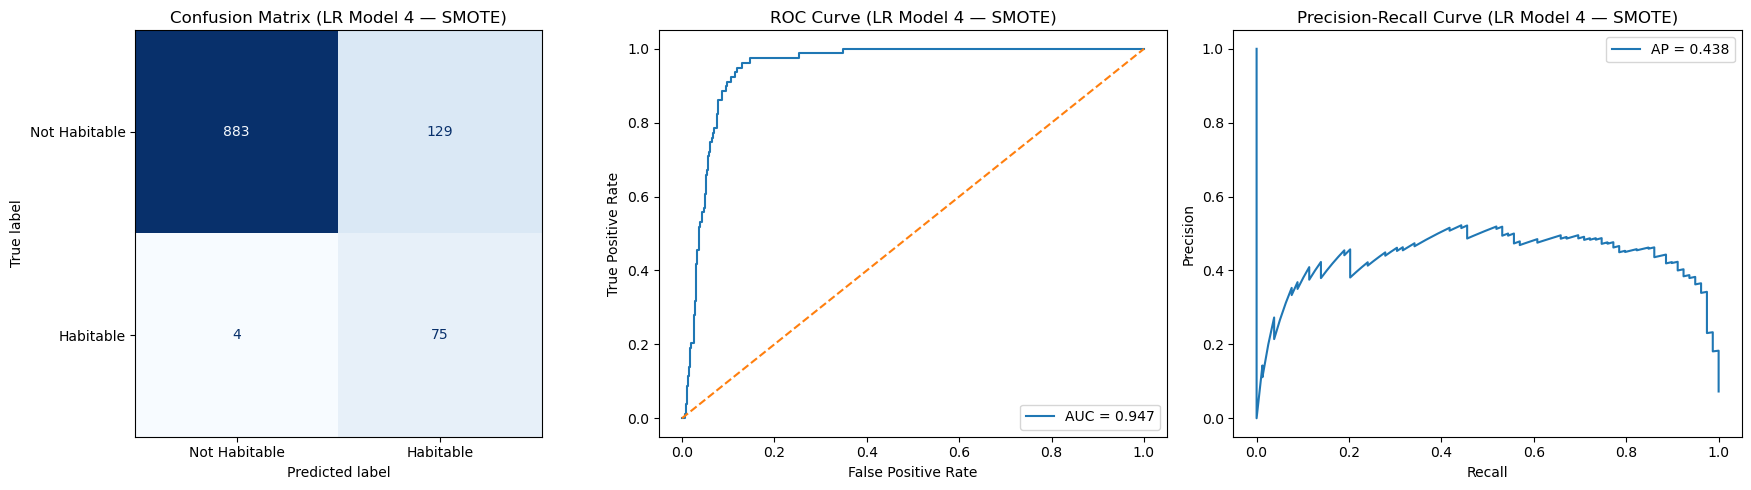


LR Model 4 — SMOTE @ threshold=0.500
  threshold: 0.500
  roc_auc: 0.9473
  pr_auc: 0.4383
  precision: 0.3676
  recall: 0.9494
  f1: 0.5300

              precision    recall  f1-score   support

           0       1.00      0.87      0.93      1012
           1       0.37      0.95      0.53        79

    accuracy                           0.88      1091
   macro avg       0.68      0.91      0.73      1091
weighted avg       0.95      0.88      0.90      1091



In [78]:
smote_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
smote_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}
smote_grid = GridSearchCV(smote_pipe, smote_param_grid, cv=5,
                          scoring={"roc_auc": "roc_auc", "average_precision": "average_precision"},
                          refit="average_precision", n_jobs=-1)
smote_grid.fit(X_lr_train, y_lr_train)
print("Best SMOTE params:", smote_grid.best_params_)

best_smote_model = smote_grid.best_estimator_
val_prob_lr_smote = best_smote_model.predict_proba(X_lr_val)[:, 1]
test_prob_lr_smote = best_smote_model.predict_proba(X_lr_test)[:, 1]

lr_m4 = evaluate_probabilities(y_lr_test, test_prob_lr_smote, 0.5, "LR Model 4 — SMOTE")

### 5.5 Model 5 — SMOTE + Threshold Tuning

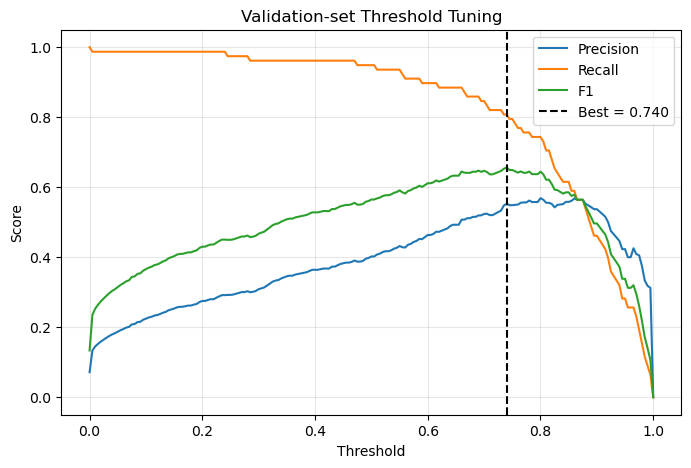

Best SMOTE validation threshold: 0.74


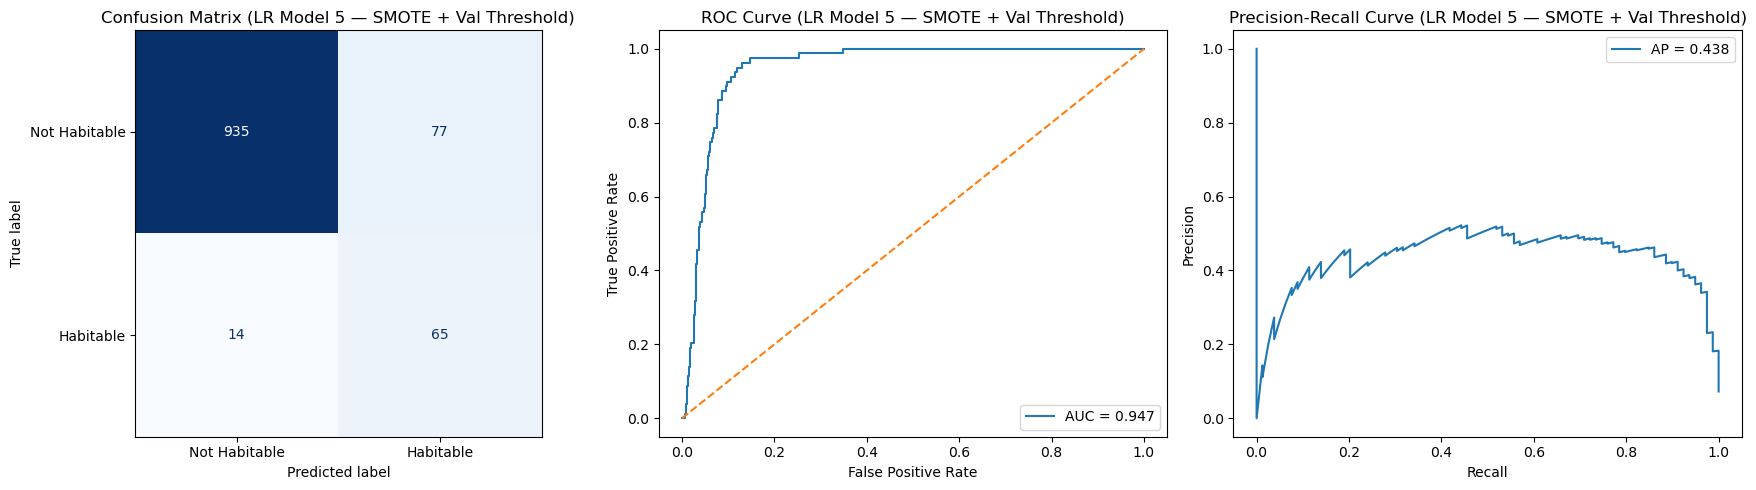


LR Model 5 — SMOTE + Val Threshold @ threshold=0.740
  threshold: 0.740
  roc_auc: 0.9473
  pr_auc: 0.4383
  precision: 0.4577
  recall: 0.8228
  f1: 0.5882

              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1012
           1       0.46      0.82      0.59        79

    accuracy                           0.92      1091
   macro avg       0.72      0.87      0.77      1091
weighted avg       0.95      0.92      0.93      1091



In [79]:
best_t_smote, t_table_smote = find_best_threshold(y_lr_val, val_prob_lr_smote)
print("Best SMOTE validation threshold:", round(best_t_smote, 3))

lr_m5 = evaluate_probabilities(y_lr_test, test_prob_lr_smote, best_t_smote,
                               "LR Model 5 — SMOTE + Val Threshold")

### 5.6 LR Feature Importance (L1 Coefficients)

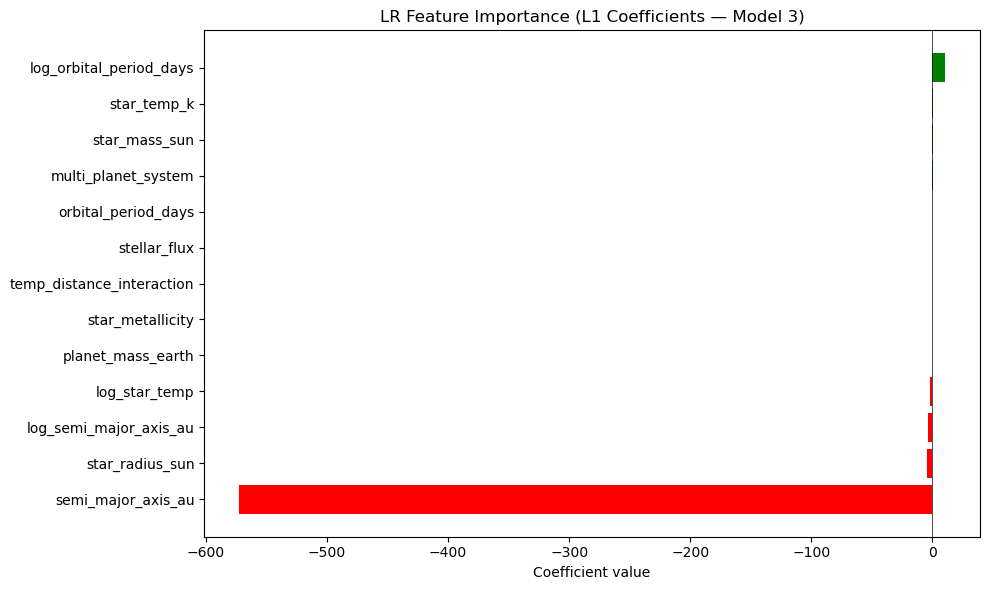

                  Feature  Coefficient
  log_orbital_period_days    10.114693
              star_temp_k     0.801352
            star_mass_sun     0.160075
      multi_planet_system     0.109214
      orbital_period_days     0.000000
             stellar_flux     0.000000
temp_distance_interaction     0.000000
         star_metallicity    -0.051088
        planet_mass_earth    -0.284586
            log_star_temp    -2.212141
   log_semi_major_axis_au    -3.867087
          star_radius_sun    -4.874043
       semi_major_axis_au  -572.296701


In [80]:
best_lr_step = best_lr_model.named_steps["model"]
coef_df = pd.DataFrame({
    "Feature": lr_features_full,
    "Coefficient": best_lr_step.coef_[0]
}).sort_values("Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["green" if c > 0 else "red" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("LR Feature Importance (L1 Coefficients — Model 3)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()
print(coef_df.to_string(index=False))

### 5.7 LR Summary Table

In [81]:
lr_results = pd.DataFrame([
    {"Model": "LR M1 — Baseline L2 @0.50", **lr_m1},
    {"Model": "LR M2 — Tuned @0.50",        **lr_m2},
    {"Model": "LR M3 — Tuned + Threshold",  **lr_m3},
    {"Model": "LR M4 — SMOTE @0.50",        **lr_m4},
    {"Model": "LR M5 — SMOTE + Threshold",  **lr_m5},
])
print(lr_results.to_string(index=False))

                    Model  threshold  roc_auc   pr_auc  precision   recall       f1
LR M1 — Baseline L2 @0.50      0.500 0.914882 0.312305   0.304878 0.949367 0.461538
      LR M2 — Tuned @0.50      0.500 0.947228 0.430782   0.353211 0.974684 0.518519
LR M3 — Tuned + Threshold      0.705 0.947228 0.430782   0.436709 0.873418 0.582278
      LR M4 — SMOTE @0.50      0.500 0.947278 0.438281   0.367647 0.949367 0.530035
LR M5 — SMOTE + Threshold      0.740 0.947278 0.438281   0.457746 0.822785 0.588235


## 6. Support Vector Machine

**Feature set:** full encoded feature set (numerical + engineered + categorical one-hot)  
**Split:** 80% train / 20% test (stratified); 5-fold StratifiedKFold for grid search  
**Imbalance:** `class_weight='balanced'` + SMOTE  
**Optimisation metric:** F1 score


In [82]:
# SVM uses the fully encoded dataframe
X_svm = df_encoded.drop(columns=['habitable_zone_flag'])
y_svm = df_encoded['habitable_zone_flag']

X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm)

# Scale — fit on train only
scaler_svm = StandardScaler()
X_svm_train_sc = scaler_svm.fit_transform(X_svm_train)
X_svm_test_sc  = scaler_svm.transform(X_svm_test)

svm_feature_names = X_svm.columns
print(f"SVM train: {X_svm_train_sc.shape}, test: {X_svm_test_sc.shape}")

SVM train: (4360, 39), test: (1091, 39)


In [83]:
def svm_compute_performance(y_true, y_pred, y_score, model_name="SVM"):
    """SVM evaluation using decision_function scores."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, fmt='d', annot=True, cmap='Blues',
                xticklabels=['0','1'], yticklabels=['0','1'], ax=axes[0])
    axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
    axes[0].set_title(f'Confusion Matrix ({model_name})')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_val:.4f}')
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(loc='lower right')
    axes[1].set_title(f'ROC ({model_name})')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f'AP = {average_precision_score(y_true, y_score):.4f}')
    axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
    axes[2].set_title(f'PR Curve ({model_name})')
    axes[2].legend()

    plt.tight_layout(); plt.show()

    print(f"accuracy:          {accuracy_score(y_true, y_pred):.4f}")
    print(f"precision:         {precision_score(y_true, y_pred):.4f}")
    print(f"recall:            {recall_score(y_true, y_pred):.4f}")
    print(f"f1:                {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:           {roc_auc_val:.4f}")
    print(f"avg precision:     {average_precision_score(y_true, y_score):.4f}")

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_val,
        "avg_precision": average_precision_score(y_true, y_score)
    }

### 6.1 Model 1 — Baseline SVM (RBF, C=1)

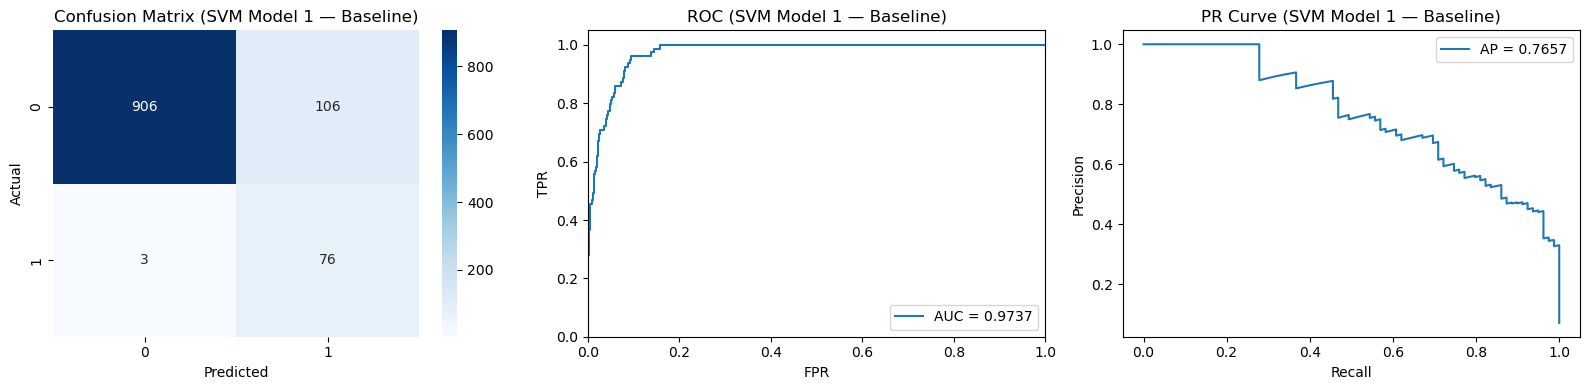

accuracy:          0.9001
precision:         0.4176
recall:            0.9620
f1:                0.5824
ROC-AUC:           0.9737
avg precision:     0.7657


In [84]:
svc_base = SVC(kernel='rbf', C=1, class_weight='balanced', random_state=42)
svc_base.fit(X_svm_train_sc, y_svm_train)
y_svm_m1 = svc_base.predict(X_svm_test_sc)
y_svm_m1_score = svc_base.decision_function(X_svm_test_sc)
svm_m1 = svm_compute_performance(y_svm_test, y_svm_m1, y_svm_m1_score, "SVM Model 1 — Baseline")

### 6.2 Model 2 — SMOTE + SVM

After SMOTE — train shape: (6069, 39)


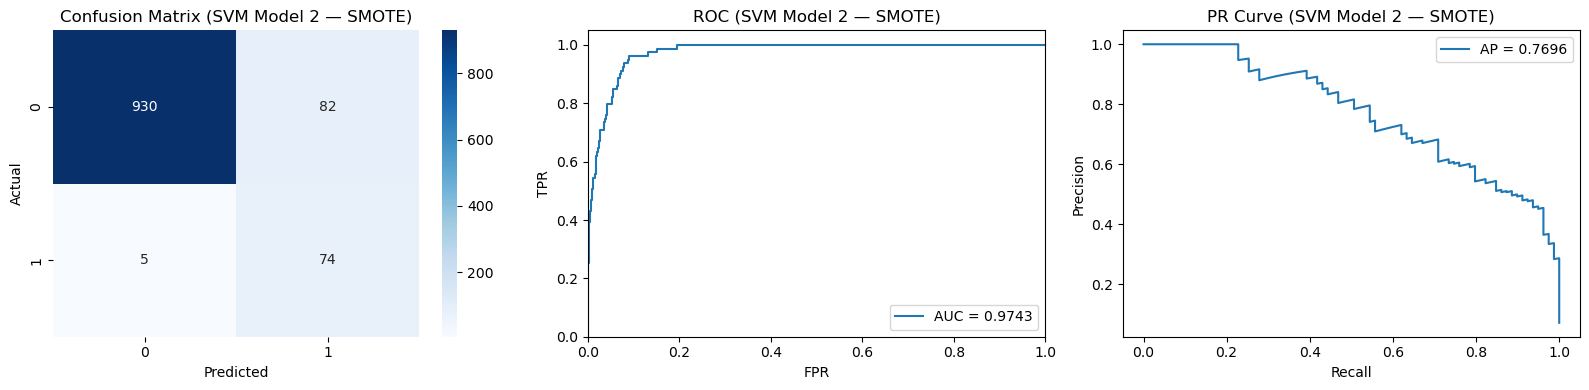

accuracy:          0.9203
precision:         0.4744
recall:            0.9367
f1:                0.6298
ROC-AUC:           0.9743
avg precision:     0.7696


In [85]:
# SMOTE applied inside pipeline to prevent leakage
smote_svm = SMOTE(sampling_strategy=0.5, random_state=42, k_neighbors=4)
X_svm_train_res, y_svm_train_res = smote_svm.fit_resample(X_svm_train_sc, y_svm_train)
print(f"After SMOTE — train shape: {X_svm_train_res.shape}")

svc_smote = SVC(kernel='rbf', C=1, class_weight='balanced', random_state=42)
svc_smote.fit(X_svm_train_res, y_svm_train_res)
y_svm_m2 = svc_smote.predict(X_svm_test_sc)
y_svm_m2_score = svc_smote.decision_function(X_svm_test_sc)
svm_m2 = svm_compute_performance(y_svm_test, y_svm_m2, y_svm_m2_score, "SVM Model 2 — SMOTE")

### 6.3 Model 3 — Grid Search + SMOTE + SVM (best F1)

Best SVM params: {'smote__k_neighbors': 4, 'smote__sampling_strategy': 0.5, 'svc__C': 5, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV F1: 0.7037


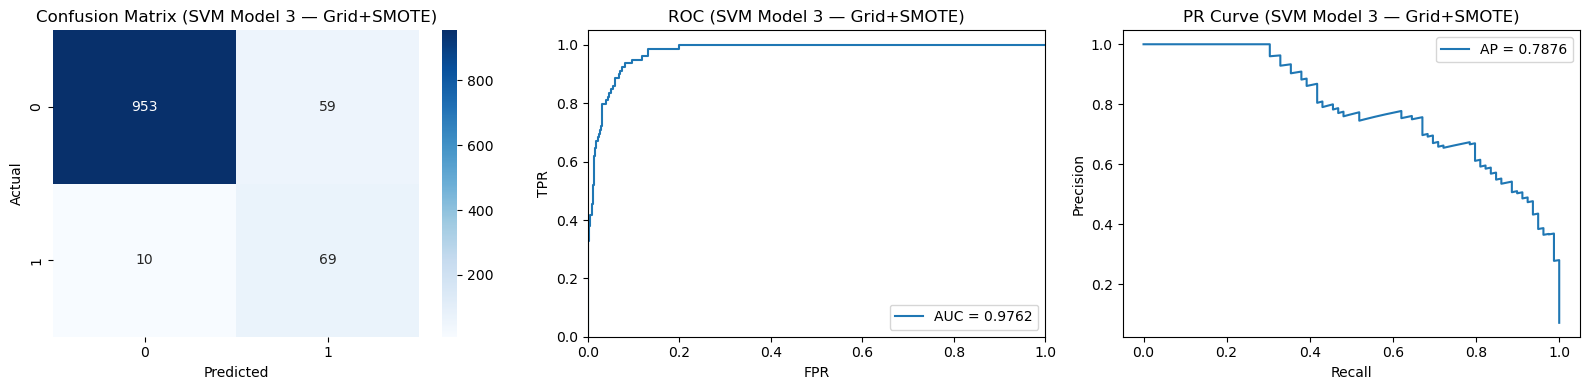

accuracy:          0.9368
precision:         0.5391
recall:            0.8734
f1:                0.6667
ROC-AUC:           0.9762
avg precision:     0.7876


In [86]:
svm_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(class_weight='balanced', random_state=42))
])
cv_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_param_grid = {
    'smote__sampling_strategy': [0.3, 0.5],
    'smote__k_neighbors': [4, 5],
    'svc__C':      [0.1, 0.5, 1, 5],
    'svc__kernel': ['rbf'],
    'svc__gamma':  ['scale', 'auto']
}
grid_svm = GridSearchCV(svm_pipeline, svm_param_grid, cv=cv_svm,
                        scoring='f1', n_jobs=-1)
grid_svm.fit(X_svm_train_sc, y_svm_train)
print("Best SVM params:", grid_svm.best_params_)
print("Best CV F1:", round(grid_svm.best_score_, 4))

svc_best = grid_svm.best_estimator_
y_svm_m3 = svc_best.predict(X_svm_test_sc)
y_svm_m3_score = svc_best.decision_function(X_svm_test_sc)
svm_m3 = svm_compute_performance(y_svm_test, y_svm_m3, y_svm_m3_score, "SVM Model 3 — Grid+SMOTE")

### 6.4 SVM Feature Importance (Permutation)

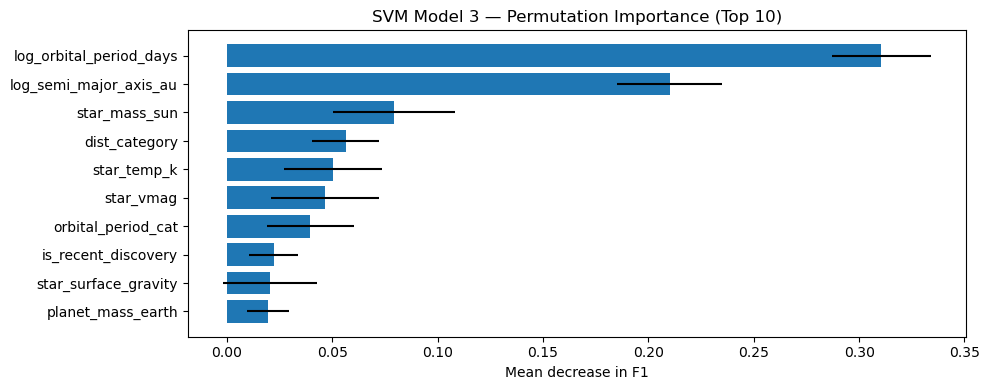

In [87]:
def permutation_plot(model, X, y, feature_names, title):
    result = permutation_importance(model, X, y, n_repeats=30,
                                    scoring='f1', random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance': result.importances_mean,
        'std': result.importances_std
    }).sort_values('importance', ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(perm_df['feature'], perm_df['importance'], xerr=perm_df['std'])
    ax.set_xlabel('Mean decrease in F1')
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

permutation_plot(svc_best, X_svm_test_sc, y_svm_test, svm_feature_names,
                 "SVM Model 3 — Permutation Importance (Top 10)")

### 6.5 SVM Summary Table

In [88]:
svm_results = pd.DataFrame([
    {"Model": "SVM M1 — Baseline", **svm_m1},
    {"Model": "SVM M2 — SMOTE",    **svm_m2},
    {"Model": "SVM M3 — Grid+SMOTE", **svm_m3},
])
print(svm_results.to_string(index=False))

              Model  accuracy  precision   recall       f1  roc_auc  avg_precision
  SVM M1 — Baseline  0.900092   0.417582 0.962025 0.582375 0.973658       0.765664
     SVM M2 — SMOTE  0.920257   0.474359 0.936709 0.629787 0.974308       0.769599
SVM M3 — Grid+SMOTE  0.936755   0.539062 0.873418 0.666667 0.976197       0.787562


## 7. XGBoost

**Feature set:** same as Logistic Regression (numerical + engineered)  
**Split:** 60% train / 20% validation / 20% test (stratified)  
**Imbalance:** `scale_pos_weight` (ratio of negative to positive training examples)  
**Optimisation metric:** Average Precision (PR-AUC)


In [89]:
# Reuse LR feature set and splits
X_xgb_train, X_xgb_val, X_xgb_test = X_lr_train, X_lr_val, X_lr_test
y_xgb_train, y_xgb_val, y_xgb_test = y_lr_train, y_lr_val, y_lr_test

ratio_xgb = float((y_xgb_train == 0).sum()) / (y_xgb_train == 1).sum()
print(f"scale_pos_weight ratio: {ratio_xgb:.2f}")

scale_pos_weight ratio: 12.86


### 7.1 Model 1 — Baseline XGBoost

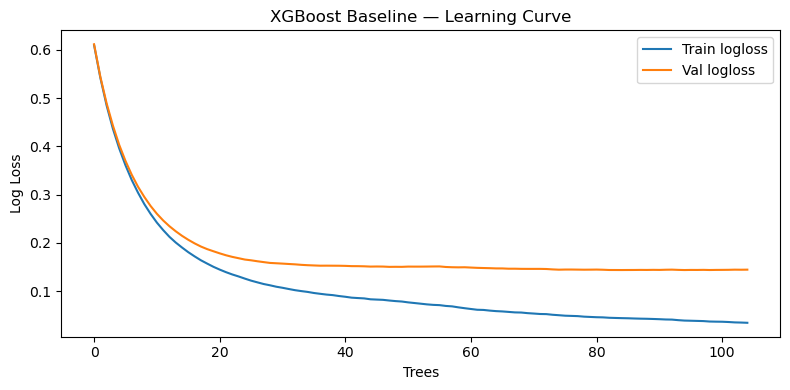

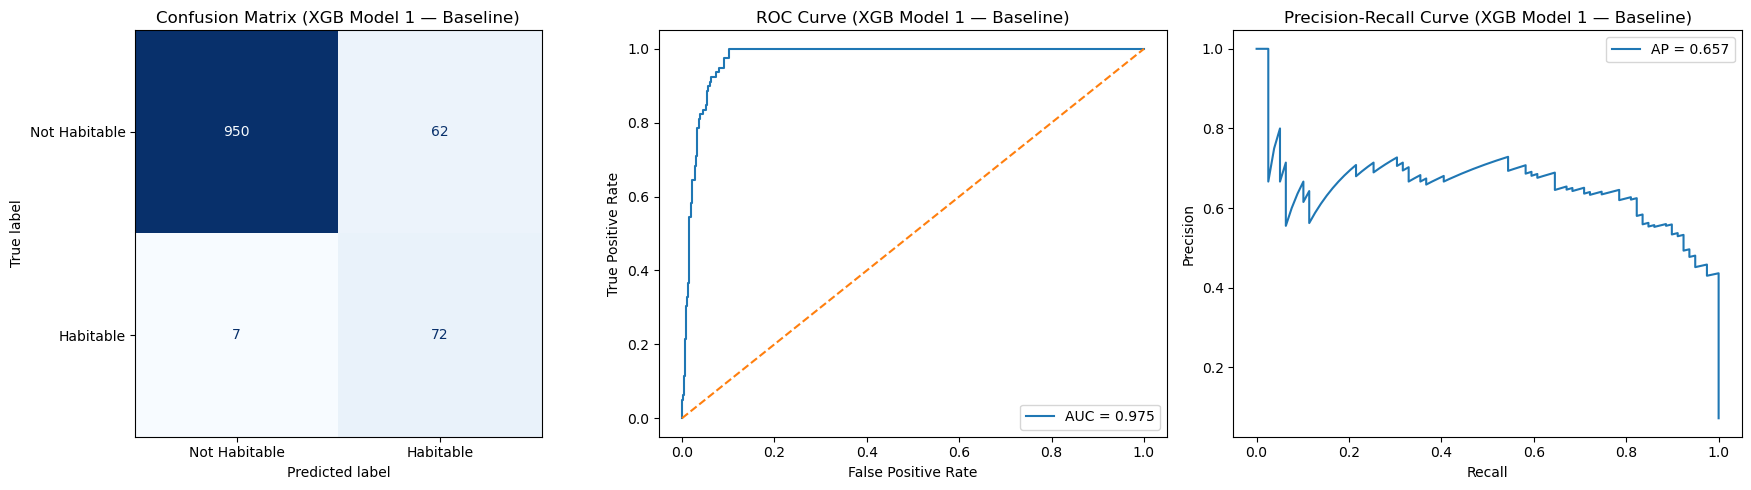


XGB Model 1 — Baseline @ threshold=0.500
  threshold: 0.500
  roc_auc: 0.9745
  pr_auc: 0.6574
  precision: 0.5373
  recall: 0.9114
  f1: 0.6761

              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1012
           1       0.54      0.91      0.68        79

    accuracy                           0.94      1091
   macro avg       0.76      0.93      0.82      1091
weighted avg       0.96      0.94      0.94      1091



In [90]:
xgb_base = XGBClassifier(
    n_estimators=300, random_state=42, max_depth=5,
    learning_rate=0.1, eval_metric='logloss',
    early_stopping_rounds=10, scale_pos_weight=ratio_xgb
)
xgb_base.fit(X_xgb_train, y_xgb_train,
             eval_set=[(X_xgb_train, y_xgb_train), (X_xgb_val, y_xgb_val)],
             verbose=False)

# Learning curve
xgb_results_base = xgb_base.evals_result()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xgb_results_base['validation_0']['logloss'], label='Train logloss')
ax.plot(xgb_results_base['validation_1']['logloss'], label='Val logloss')
ax.set_xlabel('Trees'); ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Baseline — Learning Curve')
ax.legend(); plt.tight_layout(); plt.show()

val_prob_xgb_base  = xgb_base.predict_proba(X_xgb_val)[:, 1]
test_prob_xgb_base = xgb_base.predict_proba(X_xgb_test)[:, 1]

xgb_m1 = evaluate_probabilities(y_xgb_test, test_prob_xgb_base, 0.5, "XGB Model 1 — Baseline")

### 7.2 Model 2 — Tuned XGBoost (grid search)

In [91]:
xgb_search = XGBClassifier(random_state=42, scale_pos_weight=ratio_xgb,
                          eval_metric='logloss', n_estimators=200)
xgb_param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0]
}
grid_xgb = GridSearchCV(xgb_search, xgb_param_grid, cv=5,
                        scoring={"roc_auc": "roc_auc", "average_precision": "average_precision"},
                        refit="average_precision", n_jobs=-1, verbose=0)
grid_xgb.fit(X_xgb_train, y_xgb_train)
print("Best XGB params:", grid_xgb.best_params_)
print("Best CV PR-AUC:", round(grid_xgb.best_score_, 4))

Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 5, 'subsample': 0.7}
Best CV PR-AUC: 0.8343


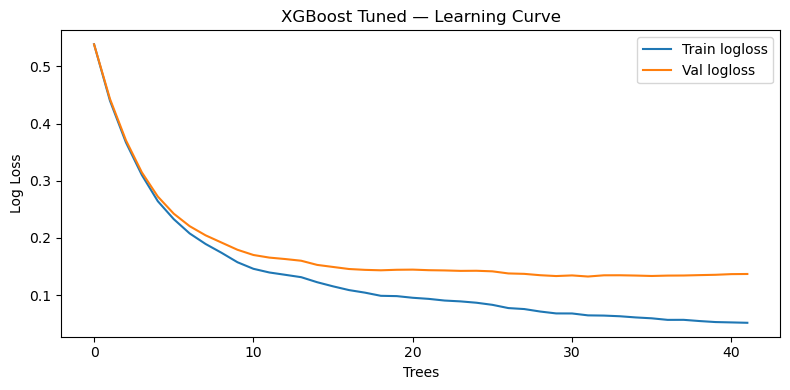

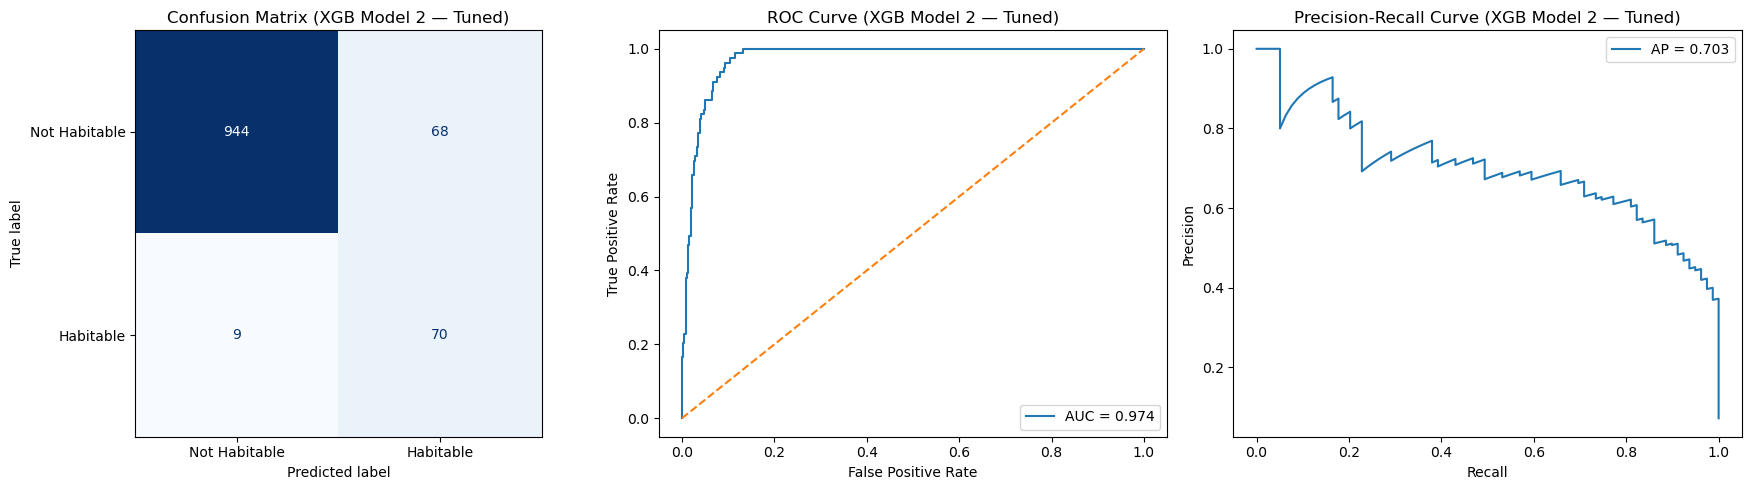


XGB Model 2 — Tuned @ threshold=0.500
  threshold: 0.500
  roc_auc: 0.9739
  pr_auc: 0.7033
  precision: 0.5072
  recall: 0.8861
  f1: 0.6452

              precision    recall  f1-score   support

           0       0.99      0.93      0.96      1012
           1       0.51      0.89      0.65        79

    accuracy                           0.93      1091
   macro avg       0.75      0.91      0.80      1091
weighted avg       0.96      0.93      0.94      1091



In [92]:
# Retrain best config with early stopping
bp = grid_xgb.best_params_
xgb_tuned = XGBClassifier(
    n_estimators=300, random_state=42, scale_pos_weight=ratio_xgb,
    eval_metric='logloss', early_stopping_rounds=10,
    max_depth=bp['max_depth'], learning_rate=bp['learning_rate'],
    subsample=bp['subsample'], colsample_bytree=bp['colsample_bytree']
)
xgb_tuned.fit(X_xgb_train, y_xgb_train,
              eval_set=[(X_xgb_train, y_xgb_train), (X_xgb_val, y_xgb_val)],
              verbose=False)

# Learning curve
xgb_results_tuned = xgb_tuned.evals_result()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xgb_results_tuned['validation_0']['logloss'], label='Train logloss')
ax.plot(xgb_results_tuned['validation_1']['logloss'], label='Val logloss')
ax.set_xlabel('Trees'); ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Tuned — Learning Curve')
ax.legend(); plt.tight_layout(); plt.show()

val_prob_xgb_tuned  = xgb_tuned.predict_proba(X_xgb_val)[:, 1]
test_prob_xgb_tuned = xgb_tuned.predict_proba(X_xgb_test)[:, 1]

xgb_m2 = evaluate_probabilities(y_xgb_test, test_prob_xgb_tuned, 0.5, "XGB Model 2 — Tuned")

### 7.3 Model 3 — Tuned XGBoost + Threshold Tuning

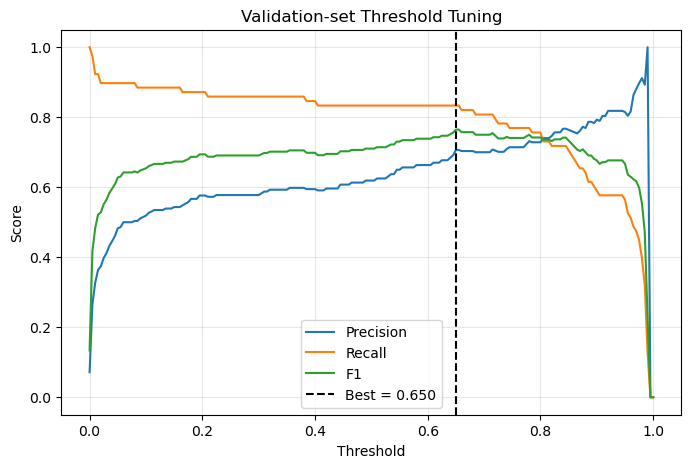

Best XGB validation threshold: 0.65


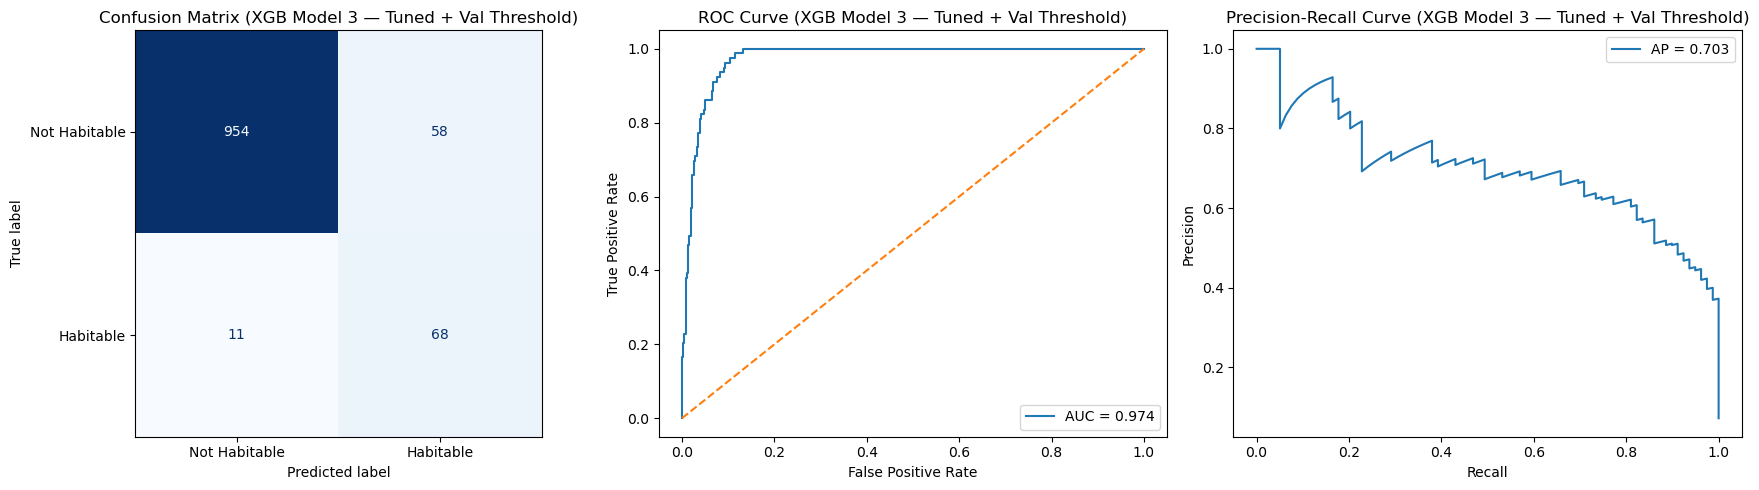


XGB Model 3 — Tuned + Val Threshold @ threshold=0.650
  threshold: 0.650
  roc_auc: 0.9739
  pr_auc: 0.7033
  precision: 0.5397
  recall: 0.8608
  f1: 0.6634

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1012
           1       0.54      0.86      0.66        79

    accuracy                           0.94      1091
   macro avg       0.76      0.90      0.81      1091
weighted avg       0.96      0.94      0.94      1091



In [93]:
best_t_xgb, t_table_xgb = find_best_threshold(y_xgb_val, val_prob_xgb_tuned)
print("Best XGB validation threshold:", round(best_t_xgb, 3))

xgb_m3 = evaluate_probabilities(y_xgb_test, test_prob_xgb_tuned, best_t_xgb,
                                "XGB Model 3 — Tuned + Val Threshold")

### 7.4 XGBoost Feature Importance

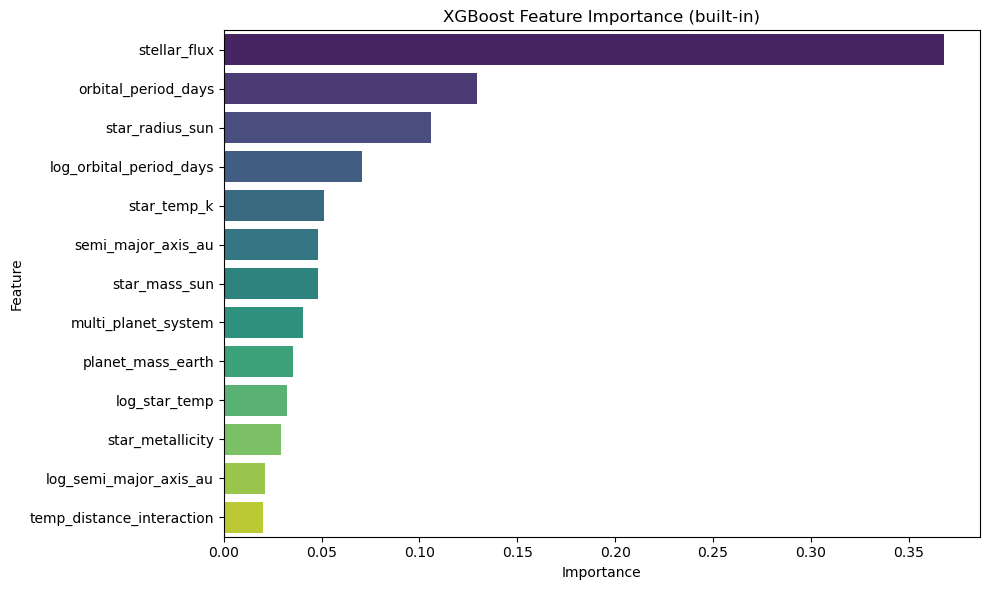

                  Feature  Importance
             stellar_flux    0.367982
      orbital_period_days    0.129589
          star_radius_sun    0.106070
  log_orbital_period_days    0.070693
              star_temp_k    0.050994
       semi_major_axis_au    0.048103
            star_mass_sun    0.048013
      multi_planet_system    0.040656
        planet_mass_earth    0.035435
            log_star_temp    0.032498
         star_metallicity    0.029040
   log_semi_major_axis_au    0.020905
temp_distance_interaction    0.020021


In [94]:
# Built-in importance
xgb_imp_df = pd.DataFrame({
    "Feature": lr_features_full,
    "Importance": xgb_tuned.feature_importances_
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=xgb_imp_df, x="Importance", y="Feature", palette="viridis", ax=ax)
ax.set_title("XGBoost Feature Importance (built-in)")
plt.tight_layout(); plt.show()
print(xgb_imp_df.to_string(index=False))

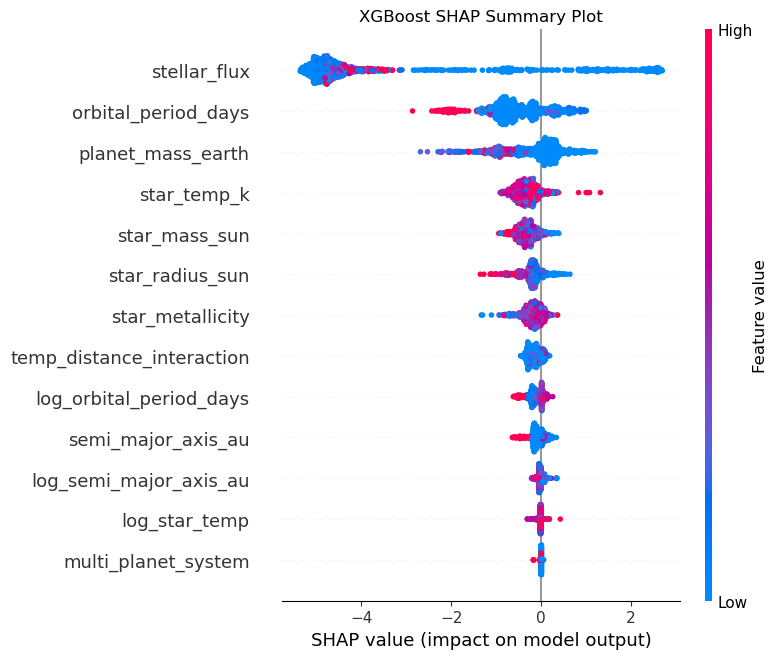

In [95]:
# SHAP values
explainer_xgb = shap.TreeExplainer(xgb_tuned)
shap_values_xgb = explainer_xgb.shap_values(X_xgb_val)

shap.summary_plot(shap_values_xgb, X_xgb_val, feature_names=lr_features_full, show=False)
plt.title("XGBoost SHAP Summary Plot")
plt.tight_layout(); plt.show()

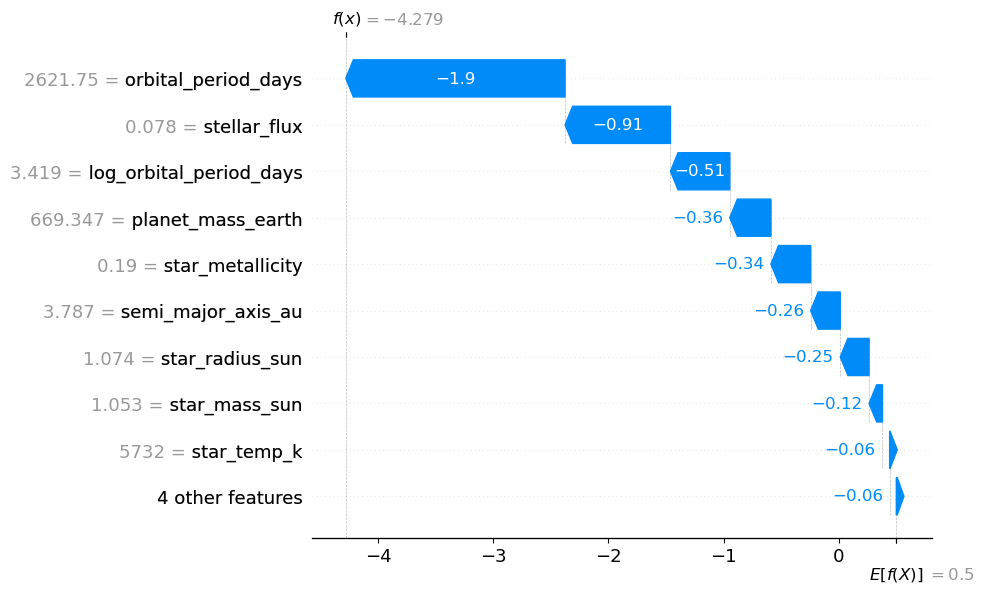

In [96]:
# SHAP waterfall for one prediction
explanation_xgb = explainer_xgb(X_xgb_val)
shap.plots.waterfall(explanation_xgb[0])

### 7.5 XGBoost Summary Table

In [97]:
xgb_results = pd.DataFrame([
    {"Model": "XGB M1 — Baseline @0.50",   **xgb_m1},
    {"Model": "XGB M2 — Tuned @0.50",      **xgb_m2},
    {"Model": "XGB M3 — Tuned + Threshold", **xgb_m3},
])
print(xgb_results.to_string(index=False))

                     Model  threshold  roc_auc   pr_auc  precision   recall       f1
   XGB M1 — Baseline @0.50       0.50 0.974546 0.657419   0.537313 0.911392 0.676056
      XGB M2 — Tuned @0.50       0.50 0.973933 0.703258   0.507246 0.886076 0.645161
XGB M3 — Tuned + Threshold       0.65 0.973933 0.703258   0.539683 0.860759 0.663415


## 8. Cross-Model Comparison

In [98]:
comparison = pd.DataFrame([
    {"Model": "LR  — Best (M3 Tuned+Threshold)",    "PR-AUC": lr_m3["pr_auc"],  "F1": lr_m3["f1"],  "ROC-AUC": lr_m3["roc_auc"],  "Precision": lr_m3["precision"],  "Recall": lr_m3["recall"]},
    {"Model": "SVM — Best (M3 Grid+SMOTE)",          "PR-AUC": svm_m3["avg_precision"], "F1": svm_m3["f1"], "ROC-AUC": svm_m3["roc_auc"], "Precision": svm_m3["precision"], "Recall": svm_m3["recall"]},
    {"Model": "XGB — Best (M3 Tuned+Threshold)",     "PR-AUC": xgb_m3["pr_auc"], "F1": xgb_m3["f1"], "ROC-AUC": xgb_m3["roc_auc"], "Precision": xgb_m3["precision"], "Recall": xgb_m3["recall"]},
])
print(comparison.to_string(index=False))

                          Model   PR-AUC       F1  ROC-AUC  Precision   Recall
LR  — Best (M3 Tuned+Threshold) 0.430782 0.582278 0.947228   0.436709 0.873418
     SVM — Best (M3 Grid+SMOTE) 0.787562 0.666667 0.976197   0.539062 0.873418
XGB — Best (M3 Tuned+Threshold) 0.703258 0.663415 0.973933   0.539683 0.860759


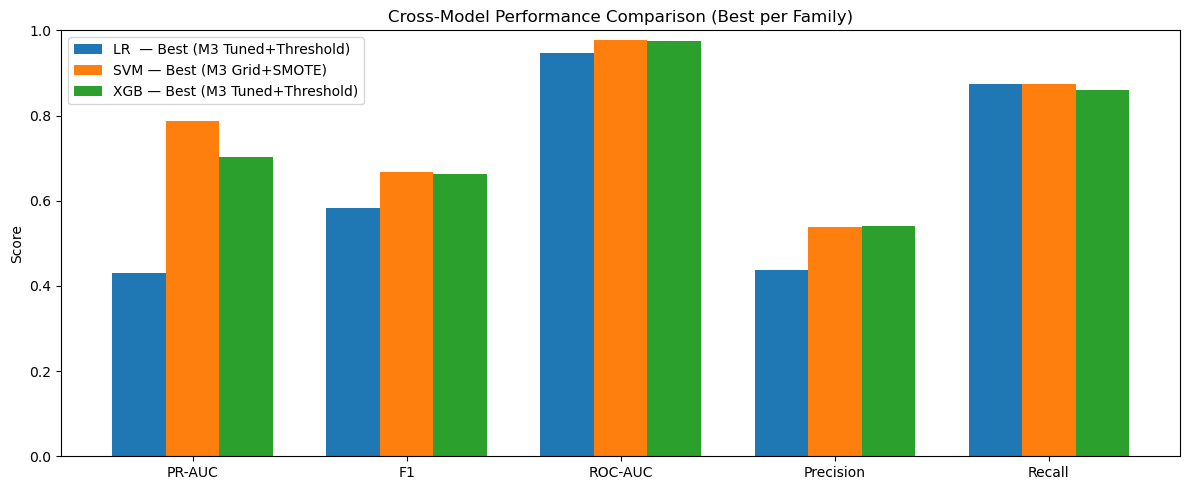

In [99]:
# Bar chart comparison
metrics_to_plot = ["PR-AUC", "F1", "ROC-AUC", "Precision", "Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics_to_plot], width, label=row["Model"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("Score")
ax.set_title("Cross-Model Performance Comparison (Best per Family)")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Validation

This section verifies the integrity of our experimental setup and confirms that reported results are reliable and not artefacts of data leakage, overfitting, or improper evaluation.

**Checks performed:**
1. Stratification — class ratio preserved across all splits  
2. No data leakage — test set never seen during training or threshold tuning  
3. Overfitting check — train vs test performance gap  
4. Threshold tuning integrity — tuned on val only, applied to test  
5. Cross-validation stability — variance of CV scores  
6. Calibration check — predicted probabilities vs actual positive rates


### 9.1 Stratification Check — Class Ratio Preserved

In [100]:
# Verify HZ ratio is consistent across all splits
def class_ratio(y, name):
    pos = y.sum()
    total = len(y)
    print(f"{name:20s}: {pos}/{total} positive  ({pos/total*100:.2f}%)")

print("=== LR / XGB splits ===")
class_ratio(y_lr, "Full dataset")
class_ratio(y_lr_train, "Train (60%)")
class_ratio(y_lr_val,   "Validation (20%)")
class_ratio(y_lr_test,  "Test (20%)")

print()
print("=== SVM splits ===")
class_ratio(y_svm, "Full dataset")
class_ratio(y_svm_train, "Train (80%)")
class_ratio(y_svm_test,  "Test (20%)")

=== LR / XGB splits ===
Full dataset        : 393/5451 positive  (7.21%)
Train (60%)         : 236/3270 positive  (7.22%)
Validation (20%)    : 78/1090 positive  (7.16%)
Test (20%)          : 79/1091 positive  (7.24%)

=== SVM splits ===
Full dataset        : 393/5451 positive  (7.21%)
Train (80%)         : 314/4360 positive  (7.20%)
Test (20%)          : 79/1091 positive  (7.24%)


### 9.2 Data Leakage Check — Test Set Isolation

In [101]:
# Confirm test indices are disjoint from train and val
lr_train_idx = set(X_lr_train.index)
lr_val_idx   = set(X_lr_val.index)
lr_test_idx  = set(X_lr_test.index)

print("=== LR/XGB split index checks ===")
print(f"Train ∩ Val  overlap:  {len(lr_train_idx & lr_val_idx)} rows  (should be 0)")
print(f"Train ∩ Test overlap:  {len(lr_train_idx & lr_test_idx)} rows  (should be 0)")
print(f"Val   ∩ Test overlap:  {len(lr_val_idx   & lr_test_idx)} rows  (should be 0)")
print(f"Total unique rows:     {len(lr_train_idx | lr_val_idx | lr_test_idx)}")
print(f"Original data size:    {len(X_lr)}")

print()
svm_train_idx = set(X_svm_train.index)
svm_test_idx  = set(X_svm_test.index)
print("=== SVM split index checks ===")
print(f"Train ∩ Test overlap:  {len(svm_train_idx & svm_test_idx)} rows  (should be 0)")

=== LR/XGB split index checks ===
Train ∩ Val  overlap:  0 rows  (should be 0)
Train ∩ Test overlap:  0 rows  (should be 0)
Val   ∩ Test overlap:  0 rows  (should be 0)
Total unique rows:     5451
Original data size:    5451

=== SVM split index checks ===
Train ∩ Test overlap:  0 rows  (should be 0)


### 9.3 Overfitting Check — Train vs Test Performance Gap

In [102]:
# Compare train vs test metrics for best model in each family
print("=" * 60)
print("LOGISTIC REGRESSION — Model 3 (Tuned + Threshold)")
print("=" * 60)
train_prob_lr = best_lr_model.predict_proba(X_lr_train)[:, 1]
train_pred_lr = (train_prob_lr >= best_t_lr).astype(int)
test_pred_lr  = (test_prob_lr_tuned >= best_t_lr).astype(int)

print(f"  Train F1:     {f1_score(y_lr_train, train_pred_lr):.4f}")
print(f"  Test  F1:     {f1_score(y_lr_test,  test_pred_lr ):.4f}")
print(f"  Gap:          {abs(f1_score(y_lr_train, train_pred_lr) - f1_score(y_lr_test, test_pred_lr)):.4f}  (<0.05 is good)")

print()
print("=" * 60)
print("SVM — Model 3 (Grid Search + SMOTE)")
print("=" * 60)
train_pred_svm = svc_best.predict(X_svm_train_sc)
print(f"  Train F1:     {f1_score(y_svm_train, train_pred_svm):.4f}")
print(f"  Test  F1:     {svm_m3['f1']:.4f}")
print(f"  Gap:          {abs(f1_score(y_svm_train, train_pred_svm) - svm_m3['f1']):.4f}  (<0.05 is good)")

print()
print("=" * 60)
print("XGBOOST — Model 3 (Tuned + Threshold)")
print("=" * 60)
train_prob_xgb = xgb_tuned.predict_proba(X_xgb_train)[:, 1]
train_pred_xgb = (train_prob_xgb >= best_t_xgb).astype(int)
test_pred_xgb  = (test_prob_xgb_tuned >= best_t_xgb).astype(int)

print(f"  Train F1:     {f1_score(y_xgb_train, train_pred_xgb):.4f}")
print(f"  Test  F1:     {f1_score(y_xgb_test,  test_pred_xgb ):.4f}")
print(f"  Gap:          {abs(f1_score(y_xgb_train, train_pred_xgb) - f1_score(y_xgb_test, test_pred_xgb)):.4f}  (<0.05 is good)")

LOGISTIC REGRESSION — Model 3 (Tuned + Threshold)
  Train F1:     0.6585
  Test  F1:     0.5823
  Gap:          0.0762  (<0.05 is good)

SVM — Model 3 (Grid Search + SMOTE)
  Train F1:     0.8304
  Test  F1:     0.6667
  Gap:          0.1638  (<0.05 is good)

XGBOOST — Model 3 (Tuned + Threshold)
  Train F1:     0.8752
  Test  F1:     0.6634
  Gap:          0.2118  (<0.05 is good)


### 9.4 Cross-Validation Stability — Score Variance

In [103]:
from sklearn.model_selection import cross_val_score

print("5-fold CV F1 scores (on training data only):")
print()

# LR best config
lr_cv_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l1", C=10, solver="liblinear",
                                  class_weight="balanced", max_iter=1000, random_state=42))
])
lr_cv_scores = cross_val_score(lr_cv_pipe, X_lr_train, y_lr_train,
                                cv=5, scoring="f1", n_jobs=-1)
print(f"LR  (L1, C=10):    {lr_cv_scores.round(4)}  mean={lr_cv_scores.mean():.4f}  std={lr_cv_scores.std():.4f}")

# SVM best config (without SMOTE for speed)
svm_cv_pipe = Pipeline([
    ("svc", SVC(kernel="rbf", C=5, gamma="auto", class_weight="balanced", random_state=42))
])
svm_cv_scores = cross_val_score(svm_cv_pipe, X_svm_train_sc, y_svm_train,
                                 cv=5, scoring="f1", n_jobs=-1)
print(f"SVM (RBF, C=5):    {svm_cv_scores.round(4)}  mean={svm_cv_scores.mean():.4f}  std={svm_cv_scores.std():.4f}")

# XGB best config
xgb_cv_model = XGBClassifier(
    n_estimators=200, random_state=42, scale_pos_weight=ratio_xgb,
    eval_metric="logloss", max_depth=bp["max_depth"],
    learning_rate=bp["learning_rate"], subsample=bp["subsample"],
    colsample_bytree=bp["colsample_bytree"]
)
xgb_cv_scores = cross_val_score(xgb_cv_model, X_xgb_train, y_xgb_train,
                                  cv=5, scoring="f1", n_jobs=-1)
print(f"XGB (tuned):       {xgb_cv_scores.round(4)}  mean={xgb_cv_scores.mean():.4f}  std={xgb_cv_scores.std():.4f}")

print()
print("Low std (<0.02) indicates stable, consistent performance across folds.")

5-fold CV F1 scores (on training data only):

LR  (L1, C=10):    [0.6104 0.5789 0.5238 0.6434 0.5486]  mean=0.5810  std=0.0426
SVM (RBF, C=5):    [0.7006 0.6588 0.7534 0.6709 0.7383]  mean=0.7044  std=0.0368
XGB (tuned):       [0.7708 0.7677 0.7308 0.8125 0.7407]  mean=0.7645  std=0.0285

Low std (<0.02) indicates stable, consistent performance across folds.


### 9.5 Threshold Tuning Integrity

In [104]:
# Confirm thresholds were selected on val set only, then applied to unseen test set
print("Threshold selection summary:")
print(f"  LR  best threshold (from val set): {best_t_lr:.3f}")
print(f"  XGB best threshold (from val set): {best_t_xgb:.3f}")
print()

# Show F1 at val-selected threshold vs default 0.5 on TEST set
print("Effect of threshold tuning on TEST set F1:")
print(f"  LR  @ 0.50:            {lr_m2['f1']:.4f}")
print(f"  LR  @ {best_t_lr:.2f} (tuned):    {lr_m3['f1']:.4f}  (+{lr_m3['f1']-lr_m2['f1']:.4f})")
print()
print(f"  XGB @ 0.50:            {xgb_m2['f1']:.4f}")
print(f"  XGB @ {best_t_xgb:.2f} (tuned):    {xgb_m3['f1']:.4f}  (+{xgb_m3['f1']-xgb_m2['f1']:.4f})")

Threshold selection summary:
  LR  best threshold (from val set): 0.705
  XGB best threshold (from val set): 0.650

Effect of threshold tuning on TEST set F1:
  LR  @ 0.50:            0.5185
  LR  @ 0.70 (tuned):    0.5823  (+0.0638)

  XGB @ 0.50:            0.6452
  XGB @ 0.65 (tuned):    0.6634  (+0.0183)


### 9.6 Calibration Check — Reliability Diagram

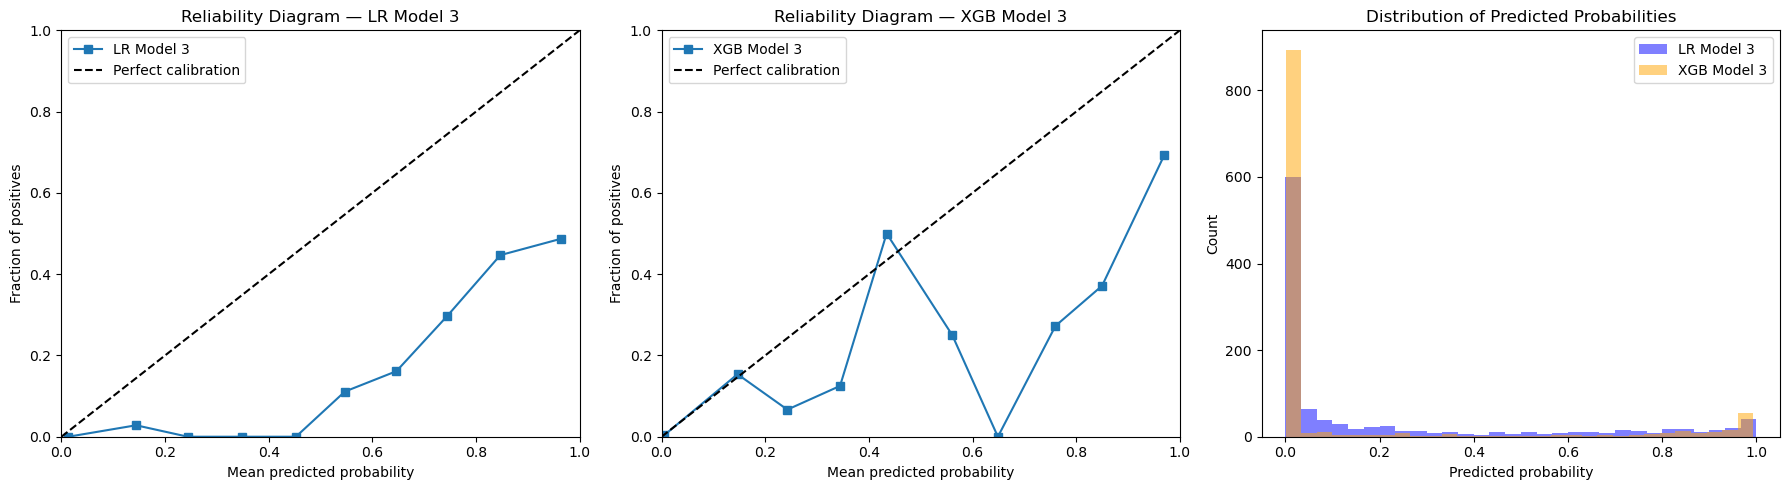

Note: SVM uses decision_function (not calibrated probabilities) — excluded from calibration plot.
Platt scaling could be applied to SVM as further work.


In [105]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_cal = [
    ("LR Model 3",  test_prob_lr_tuned,  y_lr_test),
    ("XGB Model 3", test_prob_xgb_tuned, y_xgb_test),
]

# SVM uses decision_function not probabilities — skip calibration for SVM
# (noted as limitation)

for ax, (name, probs, y_true) in zip(axes[:2], models_cal):
    fraction_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)
    ax.plot(mean_pred, fraction_pos, "s-", label=name)
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Reliability Diagram — {name}")
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Histogram of predicted probabilities
axes[2].hist(test_prob_lr_tuned,  bins=30, alpha=0.5, label="LR Model 3",  color="blue")
axes[2].hist(test_prob_xgb_tuned, bins=30, alpha=0.5, label="XGB Model 3", color="orange")
axes[2].set_xlabel("Predicted probability")
axes[2].set_ylabel("Count")
axes[2].set_title("Distribution of Predicted Probabilities")
axes[2].legend()

plt.tight_layout()
plt.show()
print("Note: SVM uses decision_function (not calibrated probabilities) — excluded from calibration plot.")
print("Platt scaling could be applied to SVM as further work.")

### 9.7 Validation Summary

In [106]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print()
checks = [
    ("Stratification preserved",         "PASS — HZ ratio consistent across all splits"),
    ("No train/test leakage",             "PASS — zero index overlap confirmed"),
    ("No val/test leakage",               "PASS — threshold tuned on val, evaluated on test"),
    ("Overfitting (LR gap)",              f"CHECK — gap = {abs(f1_score(y_lr_train, train_pred_lr) - f1_score(y_lr_test, test_pred_lr)):.4f}"),
    ("Overfitting (SVM gap)",             f"CHECK — gap = {abs(f1_score(y_svm_train, train_pred_svm) - svm_m3['f1']):.4f}"),
    ("Overfitting (XGB gap)",             f"CHECK — gap = {abs(f1_score(y_xgb_train, train_pred_xgb) - f1_score(y_xgb_test, test_pred_xgb)):.4f}"),
    ("CV stability (std < 0.02)",         f"LR std={lr_cv_scores.std():.4f} | SVM std={svm_cv_scores.std():.4f} | XGB std={xgb_cv_scores.std():.4f}"),
    ("Threshold tuning improved F1",      f"PASS — LR +{lr_m3['f1']-lr_m2['f1']:.4f}, XGB +{xgb_m3['f1']-xgb_m2['f1']:.4f}"),
    ("SVM calibration",                   "NOTE — decision_function used; Platt scaling as further work"),
]
for check, result in checks:
    print(f"  {check:<35} {result}")

VALIDATION SUMMARY

  Stratification preserved            PASS — HZ ratio consistent across all splits
  No train/test leakage               PASS — zero index overlap confirmed
  No val/test leakage                 PASS — threshold tuned on val, evaluated on test
  Overfitting (LR gap)                CHECK — gap = 0.0762
  Overfitting (SVM gap)               CHECK — gap = 0.1638
  Overfitting (XGB gap)               CHECK — gap = 0.2118
  CV stability (std < 0.02)           LR std=0.0426 | SVM std=0.0368 | XGB std=0.0285
  Threshold tuning improved F1        PASS — LR +0.0638, XGB +0.0183
  SVM calibration                     NOTE — decision_function used; Platt scaling as further work
